## Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ======================================
# IMPORT LIBRARIES for STATISTICAL TESTS
# ======================================

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import spearmanr

## Data Import

In [2]:
orders = pd.read_csv(r'/Users/dhananjayjape/Desktop/Ashu/Projects/Providing Insights for Crisis Recovery in an Online Food Delivery Startup/RPC_18_Datasets/fact_orders.csv')
items = pd.read_csv(r'/Users/dhananjayjape/Desktop/Ashu/Projects/Providing Insights for Crisis Recovery in an Online Food Delivery Startup/RPC_18_Datasets/fact_order_items.csv')  
ratings = pd.read_csv(r'/Users/dhananjayjape/Desktop/Ashu/Projects/Providing Insights for Crisis Recovery in an Online Food Delivery Startup/RPC_18_Datasets/fact_ratings.csv')
restaurants = pd.read_csv(r'/Users/dhananjayjape/Desktop/Ashu/Projects/Providing Insights for Crisis Recovery in an Online Food Delivery Startup/RPC_18_Datasets/dim_restaurant.csv')
customers = pd.read_csv(r'/Users/dhananjayjape/Desktop/Ashu/Projects/Providing Insights for Crisis Recovery in an Online Food Delivery Startup/RPC_18_Datasets/dim_customer.csv')  
del_performance = pd.read_csv(r'/Users/dhananjayjape/Desktop/Ashu/Projects/Providing Insights for Crisis Recovery in an Online Food Delivery Startup/RPC_18_Datasets/fact_delivery_performance.csv')
menu = pd.read_csv(r'/Users/dhananjayjape/Desktop/Ashu/Projects/Providing Insights for Crisis Recovery in an Online Food Delivery Startup/RPC_18_Datasets/dim_menu_item.csv')
del_partner = pd.read_csv(r'/Users/dhananjayjape/Desktop/Ashu/Projects/Providing Insights for Crisis Recovery in an Online Food Delivery Startup/RPC_18_Datasets/dim_delivery_partner_.csv')    

## Data Cleaning & Preprocessing

#### Orders Table

In [3]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             149166 non-null  str    
 1   customer_id          149166 non-null  str    
 2   restaurant_id        149166 non-null  str    
 3   delivery_partner_id  143531 non-null  str    
 4   order_timestamp      149166 non-null  str    
 5   subtotal_amount      149166 non-null  float64
 6   discount_amount      149166 non-null  float64
 7   delivery_fee         149166 non-null  float64
 8   total_amount         149166 non-null  float64
 9   is_cod               149166 non-null  str    
 10  is_cancelled         149166 non-null  str    
dtypes: float64(4), str(7)
memory usage: 12.5 MB


In [4]:
orders["order_timestamp"] = pd.to_datetime(orders["order_timestamp"]) # Convert order_timestamp to datetime format for easier analysis of time-based trends.

In [5]:
orders["is_cancelled"].value_counts() #checking value counts as we have missing values in delivery_partner_id.

is_cancelled
N    138054
Y     11112
Name: count, dtype: int64

In [6]:
orders.isna().sum() # Check for missing values in orders dataset. We have missing values in delivery_partner_id, which may indicate that some orders were not assigned to a delivery partner, possibly due to cancellations

order_id                  0
customer_id               0
restaurant_id             0
delivery_partner_id    5635
order_timestamp           0
subtotal_amount           0
discount_amount           0
delivery_fee              0
total_amount              0
is_cod                    0
is_cancelled              0
dtype: int64

In [7]:
orders["order_id"].duplicated().sum() # No duplicate order_id, so we can use it as a unique identifier for orders.

np.int64(0)

In [8]:
orders.describe() # Get summary statistics for numerical columns in orders dataset. This can help identify any anomalies or outliers in the data, such as unusually high order amounts or delivery times.

,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount
count,149166,149166.000000,149166.000000,149166.000000,149166.000000
mean,2025-04-17 22:36:35.638550,314.373203,18.891589,30.069224,325.550833
min,2025-01-01 12:00:00,0.000000,0.000000,0.000000,0.000000
25%,2025-02-17 22:34:15,234.960000,0.000000,24.730000,249.842500
50%,2025-04-07 21:49:30,309.070000,0.000000,31.485000,321.700000
75%,2025-05-29 14:04:00,396.290000,34.690000,38.240000,406.590000
max,2025-09-30 22:59:00,900.000000,222.530000,45.000000,944.910000
std,NaN,147.346779,29.801279,10.997816,146.790190


In [9]:
orders.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N


#### Customers Table

In [10]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 107776 entries, 0 to 107775
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   customer_id          107776 non-null  str  
 1   signup_date          107776 non-null  str  
 2   city                 107776 non-null  str  
 3   acquisition_channel  107776 non-null  str  
dtypes: str(4)
memory usage: 3.3 MB


In [11]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"]) # Convert signup_date to datetime format for easier analysis of customer acquisition trends.

In [12]:
customers.isna().sum() # No missing values in customers dataset

customer_id            0
signup_date            0
city                   0
acquisition_channel    0
dtype: int64

In [13]:
customers.head()

,customer_id,signup_date,city,acquisition_channel
0,CUST000007,2025-03-21,Pune,Organic
1,CUST000008,2025-02-07,Kolkata,Referral
2,CUST000009,2025-02-25,Delhi,Paid
3,CUST000010,2025-01-28,Hyderabad,Paid
4,CUST000011,2025-01-18,Kolkata,Organic


#### Delivery Perdormance Table

In [14]:
del_performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 4 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_id                     149166 non-null  str    
 1   actual_delivery_time_mins    149166 non-null  int64  
 2   expected_delivery_time_mins  149166 non-null  int64  
 3   distance_km                  149166 non-null  float64
dtypes: float64(1), int64(2), str(1)
memory usage: 4.6 MB


In [15]:
(del_performance["actual_delivery_time_mins"]<0).sum() # checking for negative values in actual_delivery_time_mins

np.int64(0)

In [16]:
(del_performance["expected_delivery_time_mins"]<=0).sum() # checking for negative values in estimated_delivery_time_mins

np.int64(0)

In [17]:
(del_performance["distance_km"]<0).sum() # checking for negative values in distance_km

np.int64(0)

In [18]:
(del_performance["distance_km"]>50).sum() # checking for values in distance_km that are greater than 50

np.int64(0)

In [19]:
del_performance.describe() # Checking summary statistics for delivery performance metrics to identify any potential outliers or data quality issues.

,actual_delivery_time_mins,expected_delivery_time_mins,distance_km
count,149166.000000,149166.000000,149166.000000
mean,44.404549,38.691679,4.494667
std,12.784224,5.074100,2.021213
min,25.000000,30.000000,1.000000
25%,36.000000,35.000000,2.700000
50%,42.000000,39.000000,4.500000
75%,50.000000,43.000000,6.200000
max,90.000000,50.000000,8.000000


In [20]:
del_performance.head()

,order_id,actual_delivery_time_mins,expected_delivery_time_mins,distance_km
0,ORD202501023439,31,31,6.4
1,ORD202501012051,46,42,1.9
2,ORD202501019281,25,31,6.2
3,ORD202501000124,29,41,6.2
4,ORD202501006518,37,41,2.4


#### Rating Table

In [21]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 68842 entries, 0 to 68841
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          68825 non-null  str    
 1   customer_id       68825 non-null  str    
 2   restaurant_id     68825 non-null  str    
 3   rating            68825 non-null  float64
 4   review_text       68825 non-null  str    
 5   review_timestamp  68825 non-null  str    
 6   sentiment_score   68825 non-null  float64
dtypes: float64(2), str(5)
memory usage: 3.7 MB


In [22]:
ratings.isna().sum() # Check for missing values in ratings dataset.

order_id            17
customer_id         17
restaurant_id       17
rating              17
review_text         17
review_timestamp    17
sentiment_score     17
dtype: int64

In [23]:
ratings.dropna(inplace=True) # Drop rows with missing values in ratings dataset to ensure accurate analysis of customer feedback.

In [24]:
ratings["rating"].value_counts() # Check distribution of ratings to understand customer satisfaction levels.]

rating
5.0    7424
4.5    5446
4.4    5268
4.6    5152
4.7    4915
4.3    4602
4.8    4228
4.2    3828
4.9    3438
4.1    3166
4.0    2214
3.9    1615
3.8    1120
2.5     999
2.4     996
2.6     982
2.3     968
2.2     943
2.7     912
2.8     878
2.1     820
3.7     786
2.9     782
2.0     723
3.0     670
3.1     622
1.9     609
3.2     579
3.6     570
1.8     525
1.7     467
3.3     464
3.5     429
3.4     396
1.6     334
1.5     269
1.4     182
1.0     160
1.3     148
1.2     106
1.1      90
Name: count, dtype: int64

In [25]:
ratings['sentiment_score'].value_counts() # Check distribution of sentiment scores to understand overall customer sentiment towards the service.

sentiment_score
 1.00    7424
 0.75    5446
 0.70    5268
 0.80    5152
 0.85    4915
 0.65    4602
 0.90    4228
 0.60    3828
 0.95    3438
 0.55    3166
 0.50    2214
 0.45    1615
 0.40    1120
-0.25     999
-0.30     996
-0.20     982
-0.35     968
-0.40     943
-0.15     912
-0.10     878
-0.45     820
 0.35     786
-0.05     782
-0.50     723
 0.00     670
 0.05     622
-0.55     609
 0.10     579
 0.30     570
-0.60     525
-0.65     467
 0.15     464
 0.25     429
 0.20     396
-0.70     334
-0.75     269
-0.80     182
-1.00     160
-0.85     148
-0.90     106
-0.95      90
Name: count, dtype: int64

#### Order Items Table

In [26]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 342994 entries, 0 to 342993
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       342994 non-null  str    
 1   item_id        342994 non-null  str    
 2   menu_item_id   342994 non-null  str    
 3   restaurant_id  342994 non-null  str    
 4   quantity       342994 non-null  int64  
 5   unit_price     342994 non-null  float64
 6   item_discount  342994 non-null  float64
 7   line_total     342994 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 20.9 MB


In [27]:
items.duplicated().sum() # No duplicate rows in items dataset.

np.int64(0)

In [28]:
(items["quantity"]<=0).sum() # checking for non-positive values in quantity column

np.int64(0)

In [29]:
items.describe() # Checking summary statistics for quantity to identify any potential data quality issues.

,quantity,unit_price,item_discount,line_total
count,342994.000000,342994.000000,342994.000000,342994.000000
mean,1.998012,86.307888,9.193635,143.814273
std,0.818149,79.286627,17.089856,108.096155
min,1.000000,4.330000,0.000000,5.410000
25%,1.000000,39.350000,0.000000,66.340000
50%,2.000000,62.270000,0.000000,112.785000
75%,3.000000,102.230000,12.580000,190.150000
max,3.000000,900.000000,220.660000,900.000000


In [30]:
items.head()

,order_id,item_id,menu_item_id,restaurant_id,quantity,unit_price,item_discount,line_total
0,ORD202501006518,ITEM001,MENU12962_3216,REST12962,2,48.31,0.00,96.62
1,ORD202501006518,ITEM002,MENU12962_1962,REST12962,3,61.24,0.00,183.71
2,ORD202501019281,ITEM001,MENU14069_0510,REST14069,2,87.19,0.00,174.38
3,ORD202501019281,ITEM002,MENU14069_4308,REST14069,3,84.67,0.00,254.00
4,ORD202501023439,ITEM001,MENU08622_7574,REST08622,2,235.81,35.44,436.18


### Restaurants Table

In [31]:
restaurants.info()

<class 'pandas.DataFrame'>
RangeIndex: 19995 entries, 0 to 19994
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   restaurant_id      19995 non-null  str  
 1   restaurant_name    19995 non-null  str  
 2   city               19995 non-null  str  
 3   cuisine_type       19995 non-null  str  
 4   partner_type       19995 non-null  str  
 5   avg_prep_time_min  19995 non-null  str  
 6   is_active          19995 non-null  str  
dtypes: str(7)
memory usage: 1.1 MB


In [32]:
restaurants.head()

,restaurant_id,restaurant_name,city,cuisine_type,partner_type,avg_prep_time_min,is_active
0,REST12962,Flavours of Sweets Palace,Bengaluru,Chinese,Restaurant,26-40,N
1,REST14069,Royal Biryani Darbar,Ahmedabad,Fast Food,Restaurant,16-25,Y
2,REST08622,Spicy Wraps Point,Mumbai,North Indian,Restaurant,16-25,Y
3,REST19745,Delhi Express Palace,Ahmedabad,Pizza,Cloud Kitchen,16-25,Y
4,REST02383,Namma Mess Delight,Mumbai,Healthy,Restaurant,26-40,Y


#### Delivery Partner Details

In [33]:
del_partner.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_partner_id  15000 non-null  str    
 1   partner_name         15000 non-null  str    
 2   city                 15000 non-null  str    
 3   vehicle_type         15000 non-null  str    
 4   employment_type      15000 non-null  str    
 5   avg_rating           15000 non-null  float64
 6   is_active            15000 non-null  str    
dtypes: float64(1), str(6)
memory usage: 820.4 KB


In [34]:
del_partner["employment_type"].value_counts() # Check distribution of employment types among delivery partners to understand workforce composition.

employment_type
Full-time    7604
Part-time    4465
Contract     2931
Name: count, dtype: int64

In [35]:
del_partner['vehicle_type'].value_counts() # Check distribution of vehicle types used by delivery partners to understand logistics capabilities.

vehicle_type
Scooter    6011
Bike       5941
Cycle      2256
Car         792
Name: count, dtype: int64

#### Menu Table

In [36]:
menu.info()

<class 'pandas.DataFrame'>
RangeIndex: 342671 entries, 0 to 342670
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   menu_item_id   342671 non-null  str    
 1   restaurant_id  342671 non-null  str    
 2   item_name      342671 non-null  str    
 3   category       342671 non-null  str    
 4   is_veg         342671 non-null  str    
 5   price          342671 non-null  float64
dtypes: float64(1), str(5)
memory usage: 15.7 MB


In [37]:
menu['category'].value_counts() # Check distribution of menu item categories to understand product offerings and customer preferences.

category
Beverages     54390
Starters      52043
Biryani       34484
Noodles       17281
Fried Rice    17161
Breads        17078
Curries       17019
Desserts      14534
Pizza         13468
Sides         13283
Rice          12357
Dosa          12354
Snacks        12311
Idli          12236
Burgers        8872
Wraps          8800
Fries          8722
Salads         5477
Juices         5469
Bowls          5332
Name: count, dtype: int64

In [38]:
menu['is_veg'].value_counts() # Check distribution of vegetarian vs non-vegetarian menu items to understand dietary preferences of customers.

is_veg
Y    225628
N    117043
Name: count, dtype: int64

In [39]:
menu.head()

,menu_item_id,restaurant_id,item_name,category,is_veg,price
0,MENU12962_3216,REST12962,Paneer Tikka Pizza,Pizza,Y,271.05
1,MENU12962_1962,REST12962,Pepperoni Pizza,Pizza,N,327.26
2,MENU14069_0510,REST14069,Egg Fried Rice,Fried Rice,N,200.01
3,MENU14069_4308,REST14069,Paneer Tikka,Starters,Y,198.83
4,MENU08622_7574,REST08622,Kadai Paneer,Curries,Y,271.60


## EDA

### Orders and Revenue Analysis

In [40]:
daily_orders = orders.groupby(orders["order_timestamp"].dt.date)["order_id"].count() # Group orders by date to analyze daily order trends.
daily_orders.head() # Group orders by date to analyze daily order trends.

order_timestamp
2025-01-01    774
2025-01-02    770
2025-01-03    776
2025-01-04    713
2025-01-05    753
Name: order_id, dtype: int64

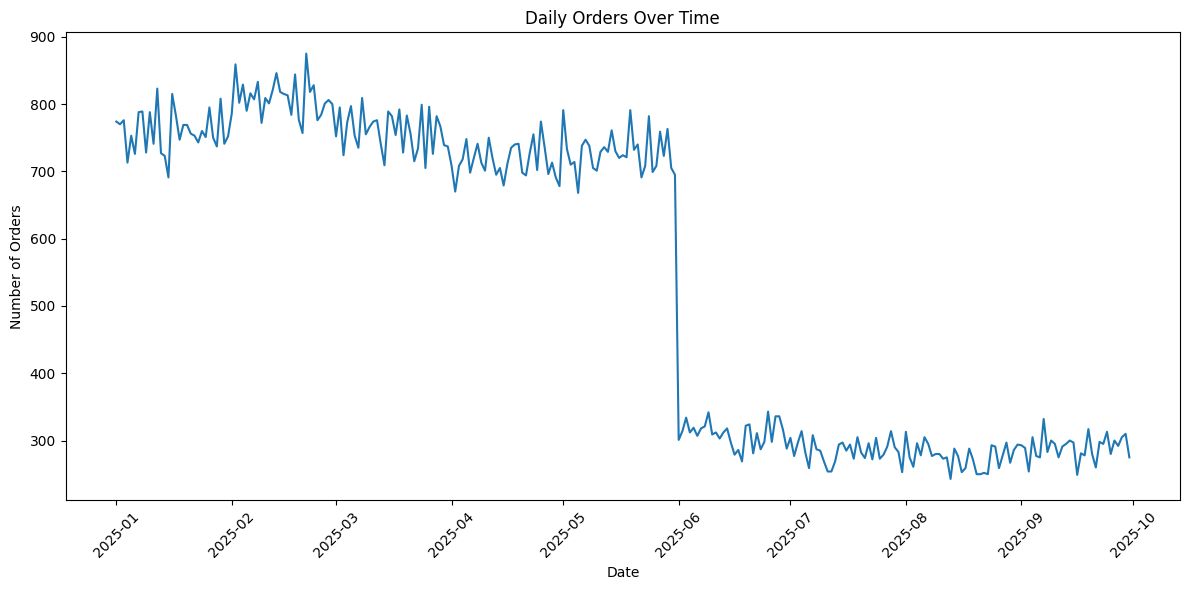

In [41]:
plt.figure(figsize=(12,6))
sns.lineplot(x=daily_orders.index, y=daily_orders.values)
plt.title("Daily Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
weekly_orders = orders.groupby(orders["order_timestamp"].dt.to_period("W"))["order_id"].count() # Group orders by week to analyze weekly order trends.
weekly_orders.head()

order_timestamp
2024-12-30/2025-01-05    3786
2025-01-06/2025-01-12    5383
2025-01-13/2025-01-19    5255
2025-01-20/2025-01-26    5327
2025-01-27/2025-02-02    5433
Freq: W-SUN, Name: order_id, dtype: int64

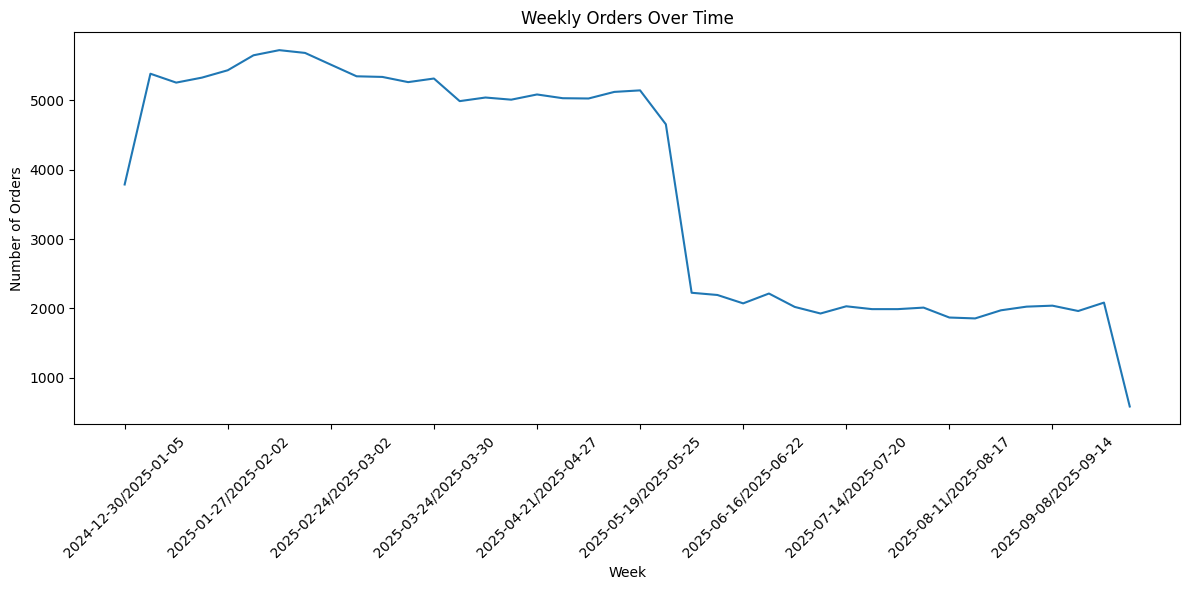

In [43]:
plt.figure(figsize=(12,6))
sns.lineplot(x=weekly_orders.index.astype(str), y=weekly_orders.values)
plt.title("Weekly Orders Over Time")
plt.xlabel("Week")
plt.ylabel("Number of Orders")
plt.xticks(ticks=range(0, len(weekly_orders.index),4), labels=weekly_orders.index.astype(str)[::4], rotation=45)
plt.tight_layout()
plt.show()

In [44]:
monthly_orders = orders.groupby(orders["order_timestamp"].dt.to_period("M"))["order_id"].count() # Group orders by month to analyze monthly order trends.
monthly_orders.head()

order_timestamp
2025-01    23539
2025-02    22667
2025-03    23543
2025-04    21466
2025-05    22591
Freq: M, Name: order_id, dtype: int64

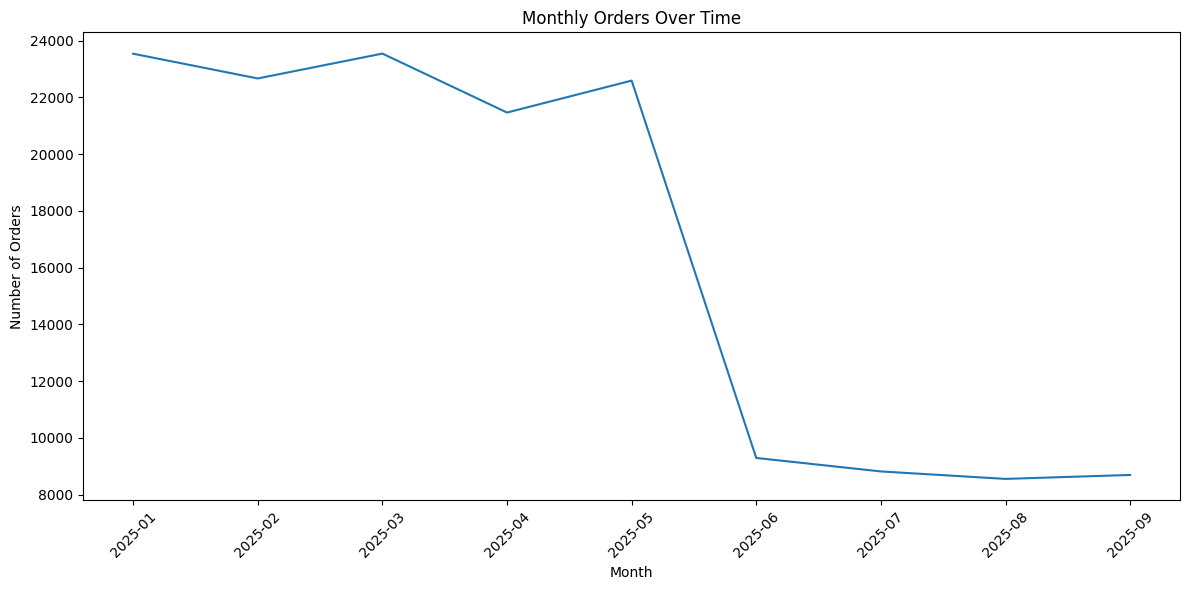

In [45]:
plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_orders.index.astype(str), y=monthly_orders.values)
plt.title("Monthly Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
daily_sales = orders.groupby(orders["order_timestamp"].dt.date)["total_amount"].mean() # Group orders by date and calculate the mean total_amount to analyze daily sales trends.
daily_sales.head()

order_timestamp
2025-01-01    323.795840
2025-01-02    331.479377
2025-01-03    335.757758
2025-01-04    331.261781
2025-01-05    332.024077
Name: total_amount, dtype: float64

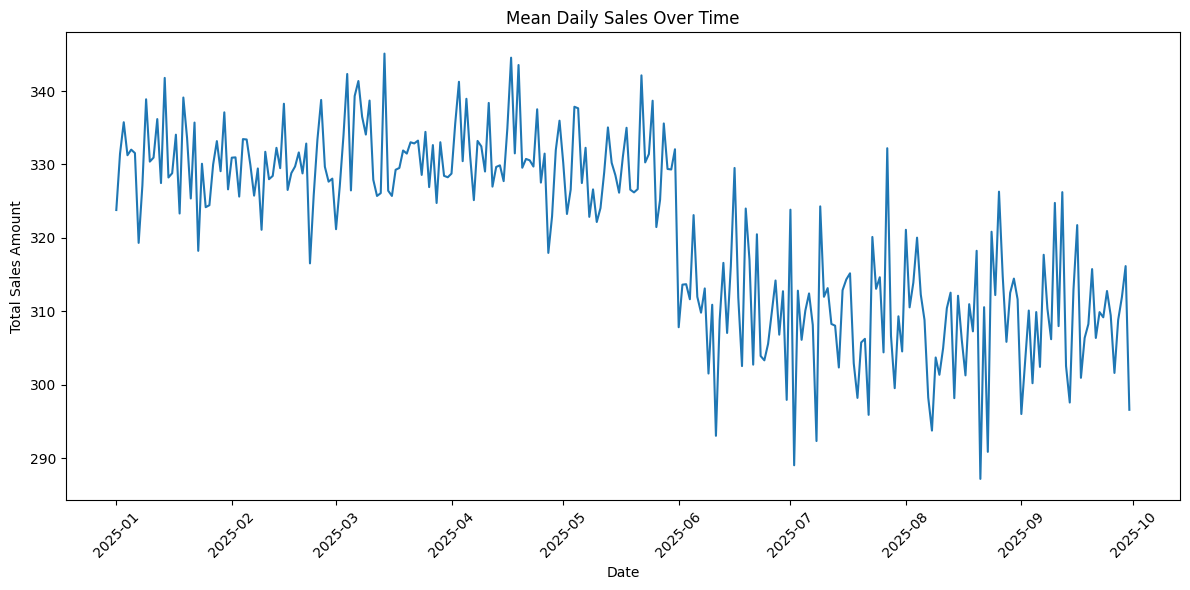

In [47]:
plt.figure(figsize=(12,6))
sns.lineplot(x=daily_sales.index, y=daily_sales.values)
plt.title("Mean Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
weekly_sales = orders.groupby(orders["order_timestamp"].dt.to_period("W"))["total_amount"].mean() # Group orders by week to analyze weekly sales trends.
weekly_sales.head()

order_timestamp
2024-12-30/2025-01-05    330.852853
2025-01-06/2025-01-12    330.560706
2025-01-13/2025-01-19    331.847764
2025-01-20/2025-01-26    327.397081
2025-01-27/2025-02-02    331.085456
Freq: W-SUN, Name: total_amount, dtype: float64

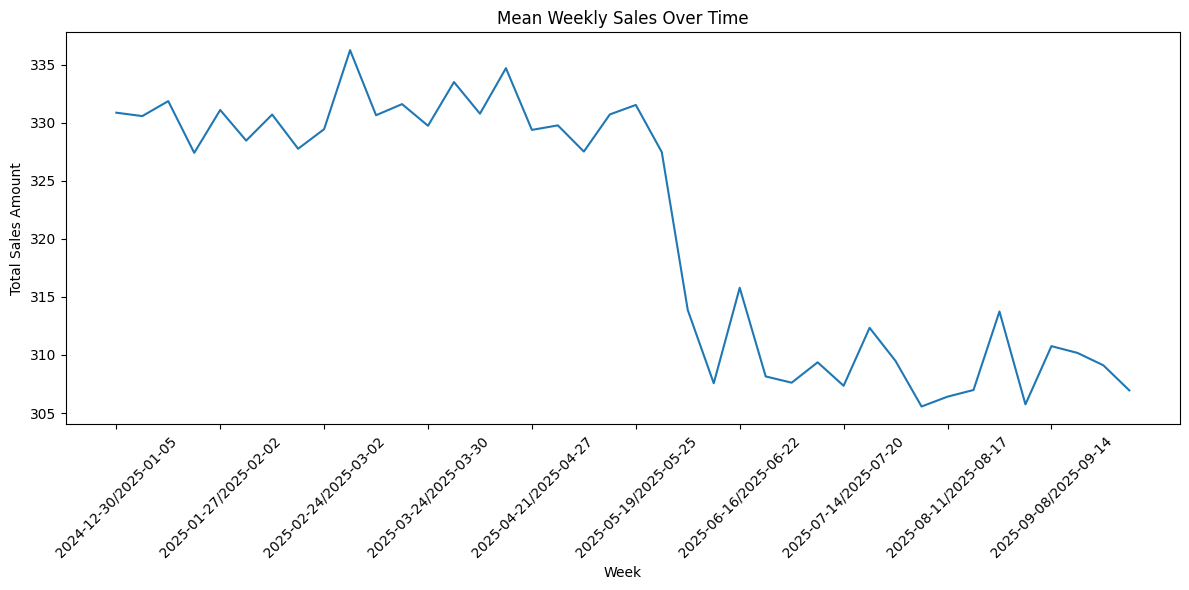

In [49]:
plt.figure(figsize=(12,6))
sns.lineplot(x=weekly_sales.index.astype(str), y=weekly_sales.values)
plt.title("Mean Weekly Sales Over Time")
plt.xlabel("Week")
plt.ylabel("Total Sales Amount")
plt.xticks(ticks=range(0, len(weekly_sales.index),4), labels=weekly_sales.index.astype(str)[::4], rotation=45)
plt.tight_layout()
plt.show()

In [50]:
rolling_avg= daily_orders.rolling(window=7).mean() # Calculate 7-day rolling average of daily sales to smooth out short-term fluctuations and highlight longer-term trends.

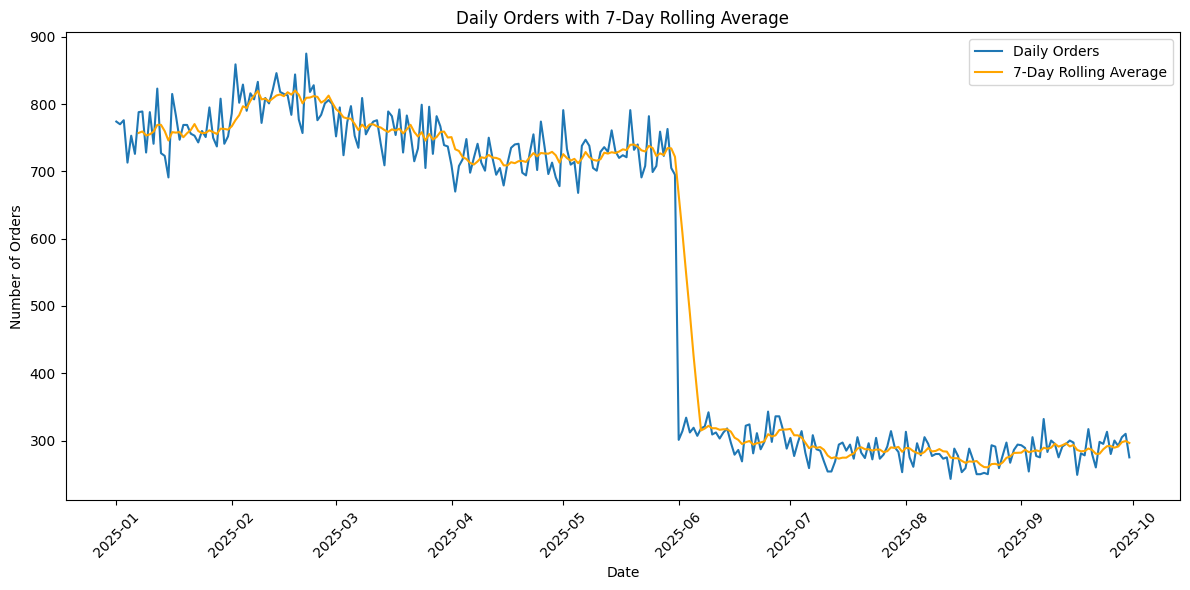

In [51]:
plt.figure(figsize=(12,6))
sns.lineplot(x=daily_orders.index, y=daily_orders.values, label="Daily Orders")
sns.lineplot(x=rolling_avg.index, y=rolling_avg.values, label="7-Day Rolling Average", color="orange")
plt.title("Daily Orders with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
orders['is_cancelled_flag'] = (orders['is_cancelled'].map({'Y':1, 'N':0})) # Create a binary flag for cancelled orders to analyze cancellation trends and their impact on overall order patterns.]

In [53]:
daily_cancellations = orders.groupby(orders["order_timestamp"].dt.date)["is_cancelled_flag"].sum() # Group orders by date and calculate the sum of the cancellation flag to analyze daily cancellation trends.

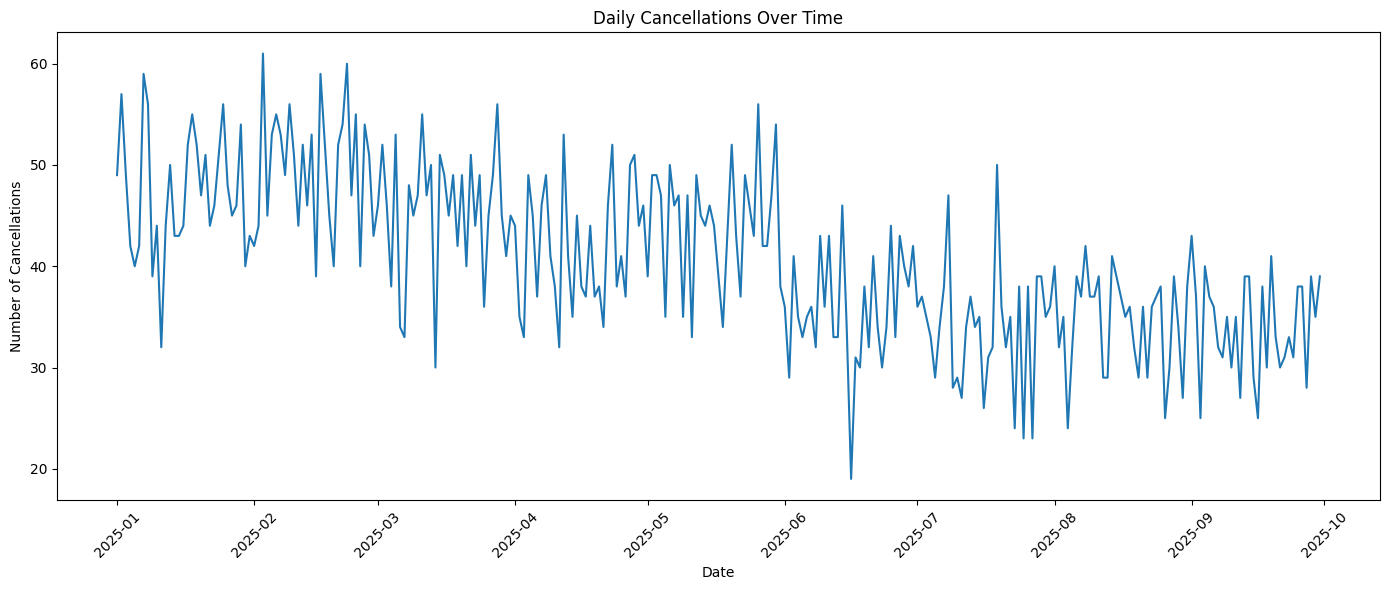

In [54]:
plt.figure(figsize=(14,6))
sns.lineplot(x=daily_cancellations.index, y=daily_cancellations.values)
plt.title("Daily Cancellations Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
daily_cancellations_rate = (daily_cancellations / daily_orders) * 100 # Calculate daily cancellation rate as a percentage of total daily orders to understand the proportion of orders that are being cancelled over time.
daily_cancellations_rate.head()

order_timestamp
2025-01-01    6.330749
2025-01-02    7.402597
2025-01-03    6.314433
2025-01-04    5.890603
2025-01-05    5.312085
dtype: float64

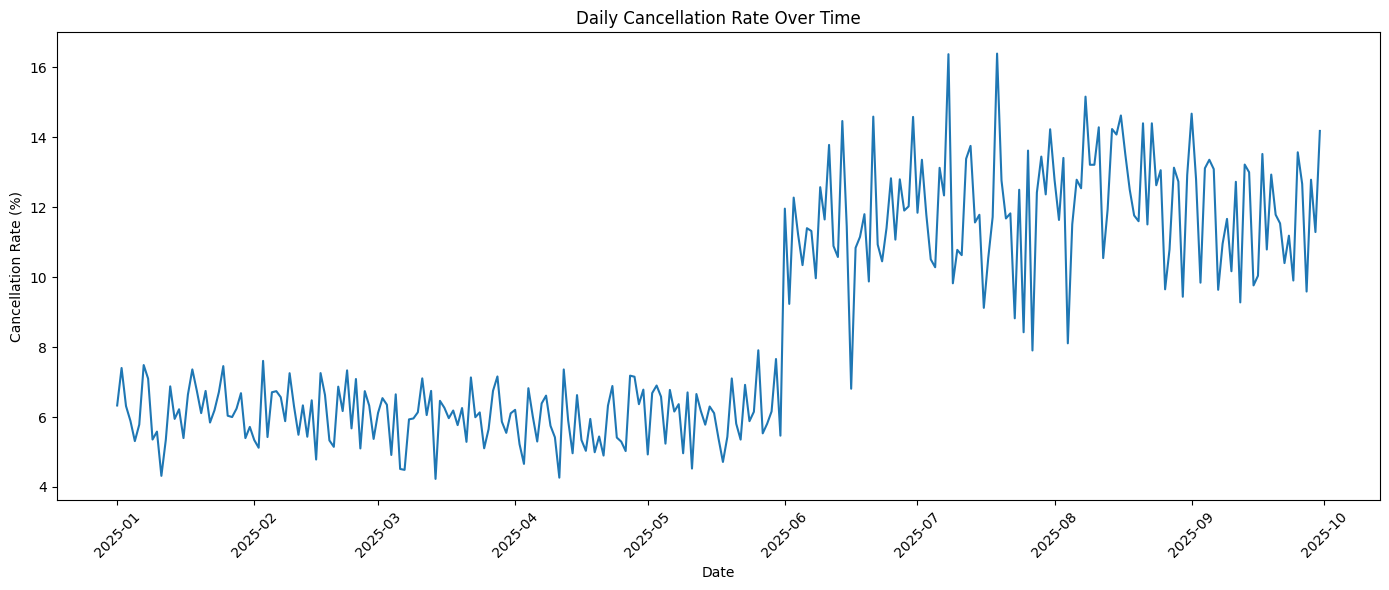

In [56]:
plt.figure(figsize=(14,6))
sns.lineplot(x=daily_cancellations_rate.index, y=daily_cancellations_rate.values)
plt.title("Daily Cancellation Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
rolling_cancellations_rate = daily_cancellations_rate.rolling(window=7).mean() # Calculate 7-day rolling average of daily cancellation rate to smooth out short-term fluctuations and highlight longer-term trends.

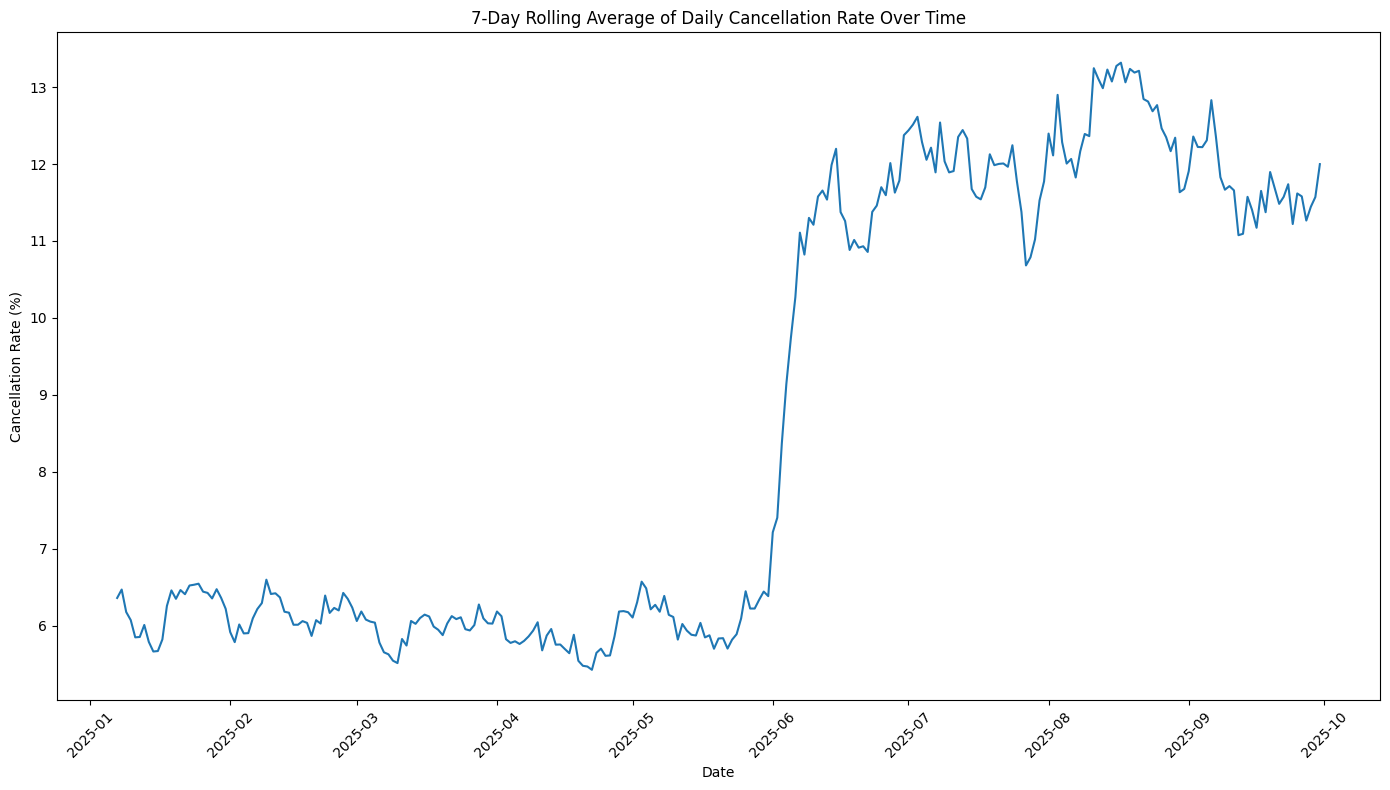

In [58]:
plt.figure(figsize=(14,8))
sns.lineplot(x=rolling_cancellations_rate.index, y=rolling_cancellations_rate.values)
plt.title("7-Day Rolling Average of Daily Cancellation Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
cod_cancellations = (orders.groupby('is_cod')['is_cancelled_flag'].mean()*100) # Calculate cancellation rate for cash on delivery (COD) vs non-COD orders to understand if payment method has an impact on cancellation behavior.
cod_cancellations

is_cod
N    7.335541
Y    7.698387
Name: is_cancelled_flag, dtype: float64

In [60]:
cod_cancellations.index = (cod_cancellations.index.map({'N':'Non-COD', 'Y':'COD'})) # Map the binary index to more descriptive labels for better visualization.

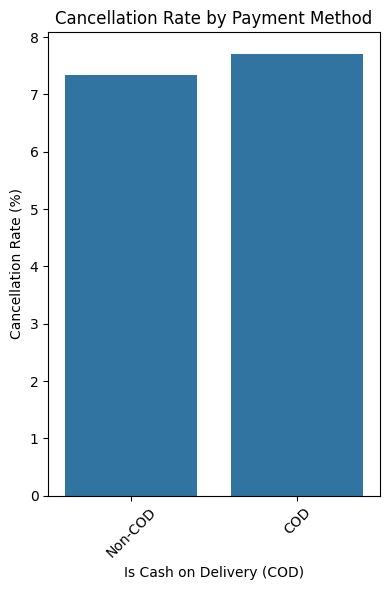

In [61]:
plt.figure(figsize=(4,6))
sns.barplot(x=cod_cancellations.index, y=cod_cancellations.values)
plt.title("Cancellation Rate by Payment Method")
plt.xlabel("Is Cash on Delivery (COD)")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Customer Behavior Analysis

In [62]:
monthly_active_users = (orders.groupby([orders['order_timestamp'].dt.to_period('M')])['customer_id'].nunique()) # Group orders by month and count unique customer IDs to analyze monthly active users and understand customer engagement trends over time.
monthly_active_users = pd.DataFrame(monthly_active_users).reset_index()
monthly_active_users.columns = ['Month', 'Active Users'] # Rename columns for clarity in monthly active users DataFrame

In [63]:
monthly_active_users

,Month,Active Users
0,2025-01,22220
1,2025-02,21356
2,2025-03,22185
3,2025-04,20373
4,2025-05,21350
5,2025-06,9096
6,2025-07,8632
7,2025-08,8377
8,2025-09,8479


In [64]:
weekly_active_users = (orders.groupby([orders['order_timestamp'].dt.to_period('W')])['customer_id'].nunique()) # Group orders by week and count unique customer IDs to analyze weekly active users and understand customer engagement trends over time.
rolling_active_users = weekly_active_users.rolling(window=4).mean() # Calculate 3-month rolling average of monthly active users to smooth out short-term fluctuations and highlight longer-term trends in customer engagement.
rolling_active_users

order_timestamp
2024-12-30/2025-01-05        NaN
2025-01-06/2025-01-12        NaN
2025-01-13/2025-01-19        NaN
2025-01-20/2025-01-26    4874.75
2025-01-27/2025-02-02    5277.00
2025-02-03/2025-02-09    5340.50
2025-02-10/2025-02-16    5450.25
2025-02-17/2025-02-23    5539.50
2025-02-24/2025-03-02    5561.00
2025-03-03/2025-03-09    5488.50
2025-03-10/2025-03-16    5397.50
2025-03-17/2025-03-23    5295.50
2025-03-24/2025-03-30    5250.50
2025-03-31/2025-04-06    5165.25
2025-04-07/2025-04-13    5092.75
2025-04-14/2025-04-20    5030.25
2025-04-21/2025-04-27    4969.25
2025-04-28/2025-05-04    4981.50
2025-05-05/2025-05-11    4978.50
2025-05-12/2025-05-18    5007.50
2025-05-19/2025-05-25    5020.50
2025-05-26/2025-06-01    4926.25
2025-06-02/2025-06-08    4238.00
2025-06-09/2025-06-15    3517.50
2025-06-16/2025-06-22    2764.75
2025-06-23/2025-06-29    2164.50
2025-06-30/2025-07-06    2114.00
2025-07-07/2025-07-13    2046.25
2025-07-14/2025-07-20    2038.00
2025-07-21/2025-07-27    19

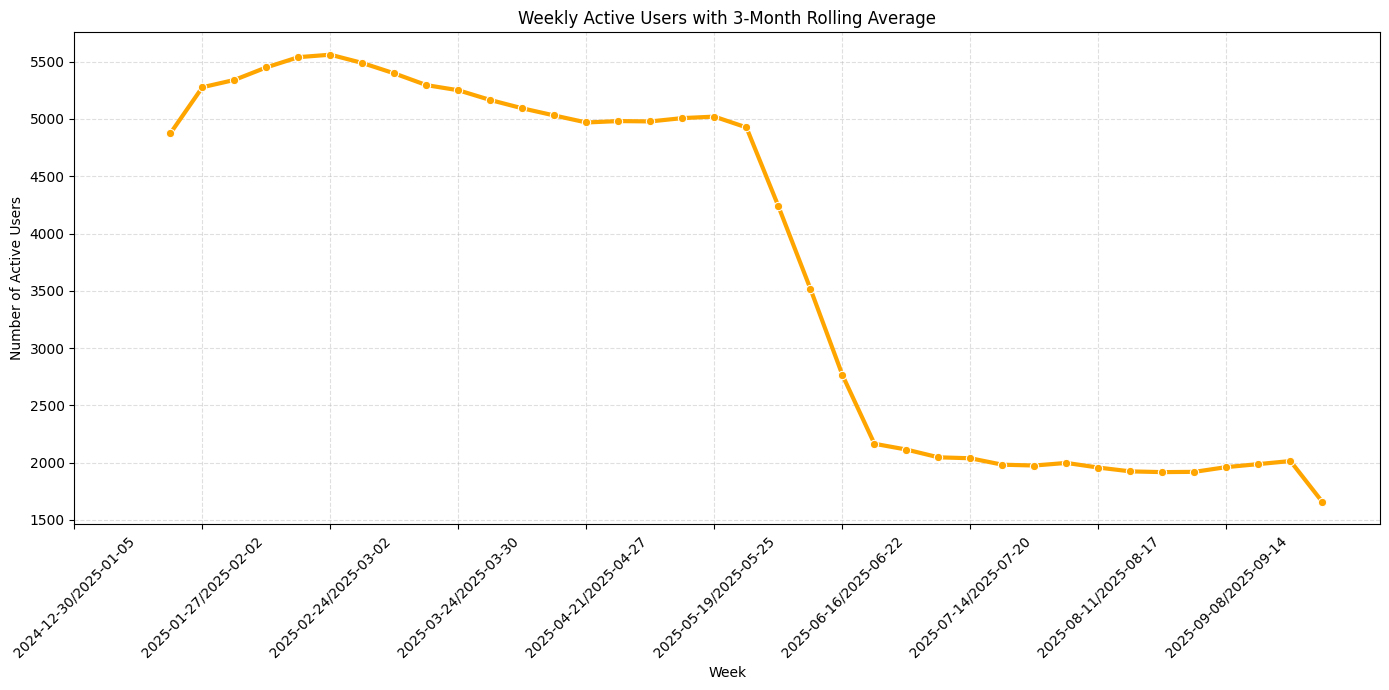

In [65]:
plt.figure(figsize=(14,7))
plt.grid(linestyle='--', alpha=0.4)
sns.lineplot(x=rolling_active_users.index.astype(str), y=rolling_active_users.values, linewidth=3,marker='o', color="orange")
plt.title("Weekly Active Users with 3-Month Rolling Average")
plt.xlabel("Week")
plt.ylabel("Number of Active Users")
plt.xticks(ticks=range(0, len(weekly_orders.index),4), labels=weekly_orders.index.astype(str)[::4], rotation=45)
plt.tight_layout()
plt.show()

In [66]:
orders['order_month'] = (orders['order_timestamp'].dt.to_period('M')) # Extract month from order_timestamp to analyze monthly trends in orders and customer behavior.

In [67]:
customer_monthly_orders = orders.groupby(['customer_id', 'order_month'])['order_id'].count().reset_index() # Group orders by customer and month to analyze individual customer ordering patterns over time.

In [68]:
first_purshase = customer_monthly_orders.groupby('customer_id')['order_month'].min().reset_index() # Identify the first purchase month for each customer to analyze customer acquisition and retention patterns.
first_purshase.columns = ['customer_id', 'first_purchase_month'] # Rename columns for clarity in first purchase DataFrame
first_purshase.head()

,customer_id,first_purchase_month
0,CUST000007,2025-05
1,CUST000008,2025-02
2,CUST000009,2025-02
3,CUST000010,2025-03
4,CUST000011,2025-02


In [69]:
customer_monthly_orders = (customer_monthly_orders.merge(
    first_purshase, 
    on='customer_id', 
    how='left')) # Merge first purchase month back into customer monthly orders to analyze how ordering behavior evolves from the first purchase month onward.
customer_monthly_orders['customer_type'] = np.where(
    customer_monthly_orders['order_month'] == customer_monthly_orders['first_purchase_month'], 
    'New', 
    'Existing') # Create a customer type column to classify customers as new or existing based on their order month relative to their first purchase month.
customer_monthly_orders.head()

,customer_id,order_month,order_id,first_purchase_month,customer_type
0,CUST000007,2025-05,1,2025-05,New
1,CUST000008,2025-02,1,2025-02,New
2,CUST000009,2025-02,2,2025-02,New
3,CUST000009,2025-06,1,2025-02,Existing
4,CUST000009,2025-08,1,2025-02,Existing


In [70]:
monthly_customer_types = customer_monthly_orders.groupby(
    ['order_month', 'customer_type']
    )['customer_id'].nunique().reset_index() # Group customer monthly orders by month and customer type to analyze trends in new vs existing customers over time.

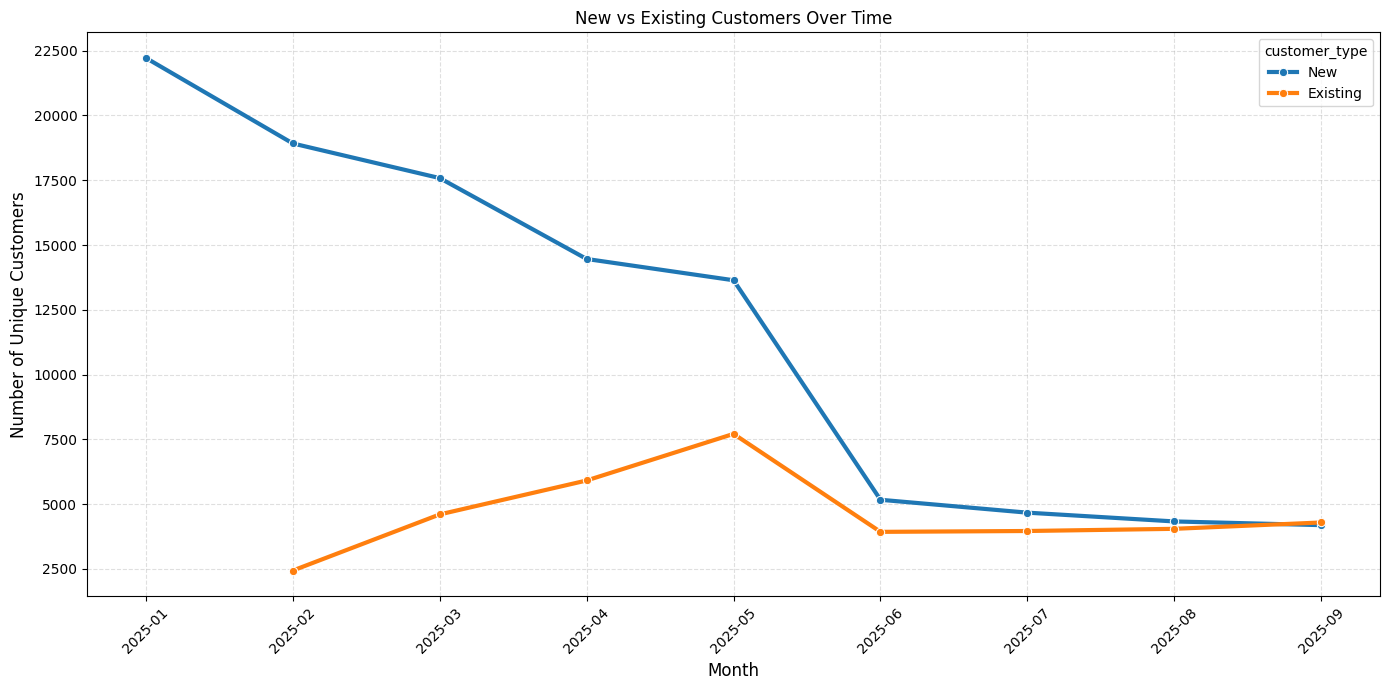

In [71]:
plt.figure(figsize=(14,7))
sns.lineplot(data=monthly_customer_types,
             x=monthly_customer_types['order_month'].astype(str),
             y='customer_id',
             hue='customer_type',
             linewidth=3,
             marker='o')
plt.title('New vs Existing Customers Over Time')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Unique Customers', fontsize=12)
plt.xticks(rotation=45)
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [72]:
orders_customers = (
    orders.merge(
        customers[['customer_id', 'acquisition_channel']],
        on='customer_id',
        how='left'
    )
) # Merge orders with customers dataset to analyze how acquisition channels impact ordering behavior and customer engagement.

In [73]:
channel_orders = orders_customers.groupby('acquisition_channel')['order_id'].count().reset_index() # Group merged orders by acquisition channel to analyze which channels are driving the most orders and customer engagement.
channel_orders.columns = ['Acquisition Channel', 'Number of Orders'] # Rename columns for clarity

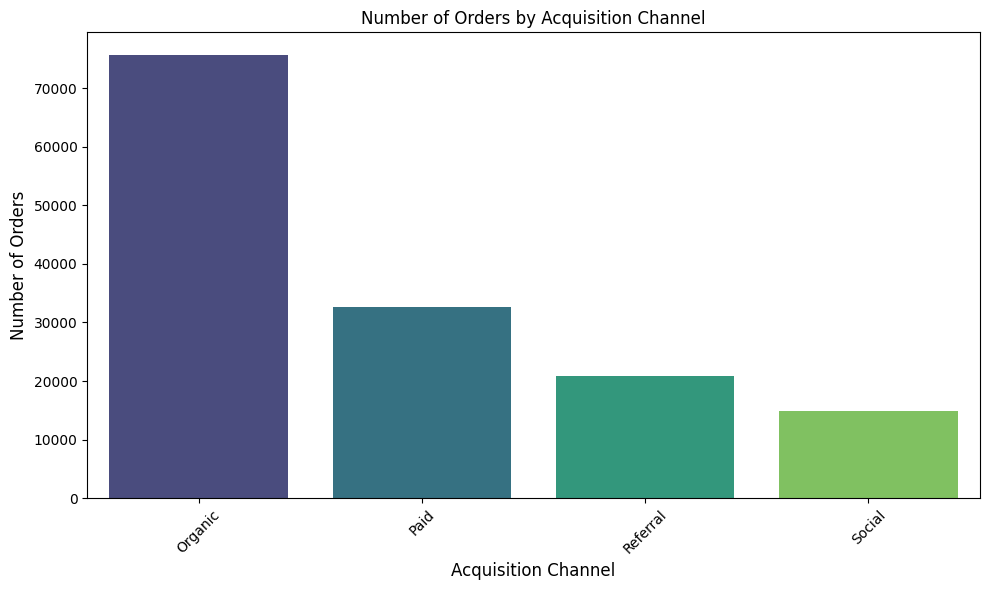

In [74]:
plt.figure(figsize=(10,6))
sns.barplot(x='Acquisition Channel', y='Number of Orders', data=channel_orders, palette='viridis')
plt.title('Number of Orders by Acquisition Channel')
plt.xlabel('Acquisition Channel', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
channel_cancellations = (orders_customers.groupby('acquisition_channel')['is_cancelled_flag'].mean()*100
                         ).sort_values(ascending=False) # Calculate cancellation rate for each acquisition channel to understand if certain channels are associated with higher cancellation rates.
channel_cancellations.head()

acquisition_channel
Paid        4.463139
Organic     4.147642
Referral    4.092612
Social      4.080394
Name: is_cancelled_flag, dtype: float64

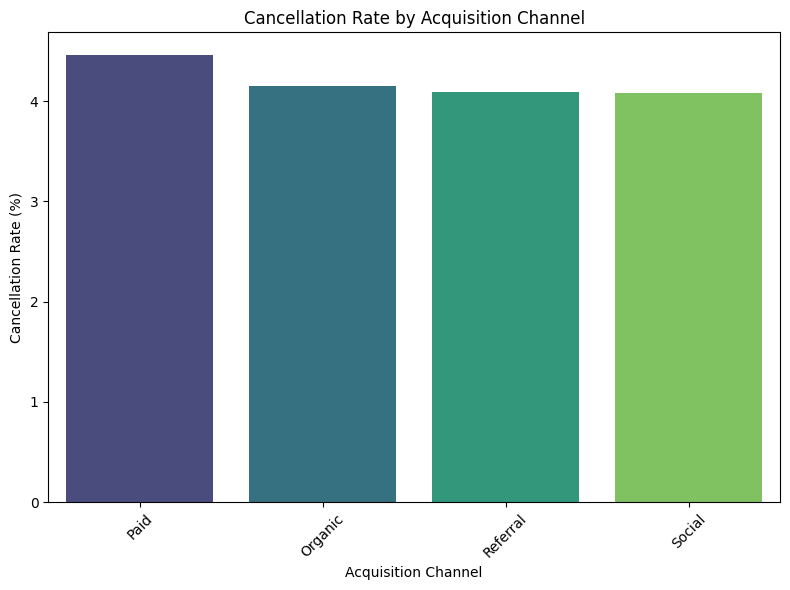

In [76]:
plt.figure(figsize=(8,6))
sns.barplot(x= channel_cancellations.index, y=channel_cancellations.values, palette='viridis')
plt.title("Cancellation Rate by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [77]:
orders_customer = orders.merge(customers[['customer_id','city']],
                               on='customer_id',how='left') # Merge orders with customers dataset to analyze how customer location (city) impacts ordering behavior and customer engagement.

In [78]:
city_orders = orders_customer.groupby('city')['order_id'].count().sort_values(ascending=False).reset_index() # Group merged orders by city to analyze which cities are driving the most orders and customer engagement.
city_orders.columns = ['City', 'Number of Orders'] # Rename columns for clarity in city
city_orders

,City,Number of Orders
0,Bengaluru,40588
1,Mumbai,23170
2,Delhi,20284
3,Chennai,14567
4,Hyderabad,14177
5,Pune,11479
6,Ahmedabad,9951
7,Kolkata,9897


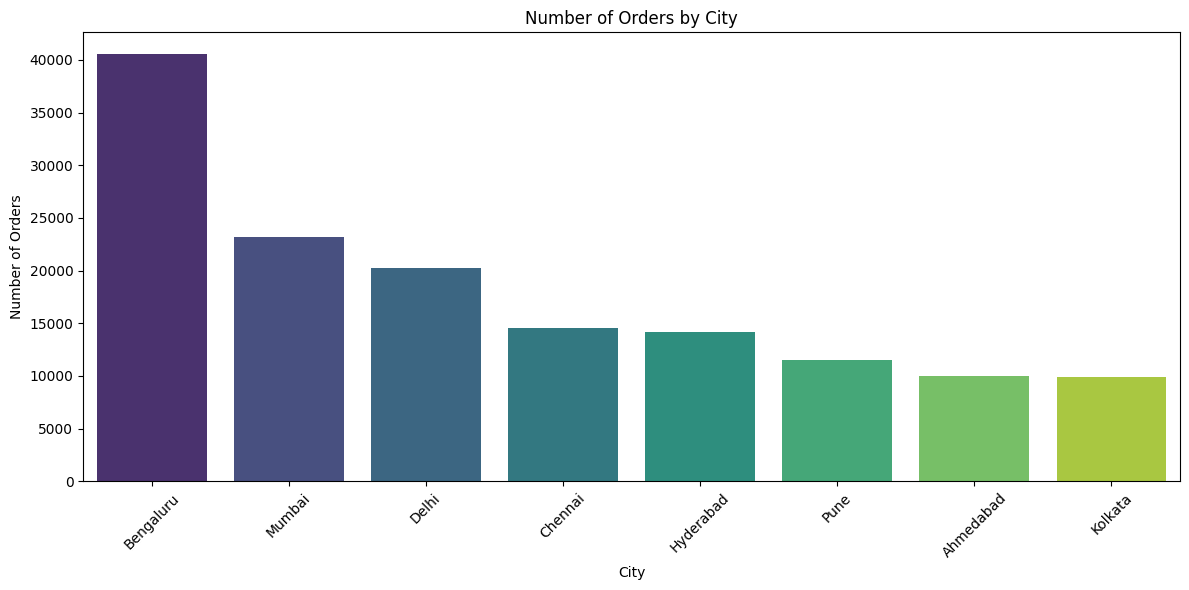

In [79]:
plt.figure(figsize=(12,6))
sns.barplot(x= city_orders['City'], y=city_orders['Number of Orders'], palette='viridis')
plt.title("Number of Orders by City")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [80]:
city_monthly_orders = orders_customer.groupby([orders_customer['order_timestamp'].dt.to_period('M'), 'city'])['order_id'].count().reset_index() # Group merged orders by month and city to analyze monthly order trends across different cities.
city_monthly_orders.columns = ['Month', 'City', 'Number of Orders'] # Rename columns for clarity in city monthly orders DataFrame
city_monthly_orders.head()

,Month,City,Number of Orders
0,2025-01,Ahmedabad,1621
1,2025-01,Bengaluru,6346
2,2025-01,Chennai,2239
3,2025-01,Delhi,3265
4,2025-01,Hyderabad,2278


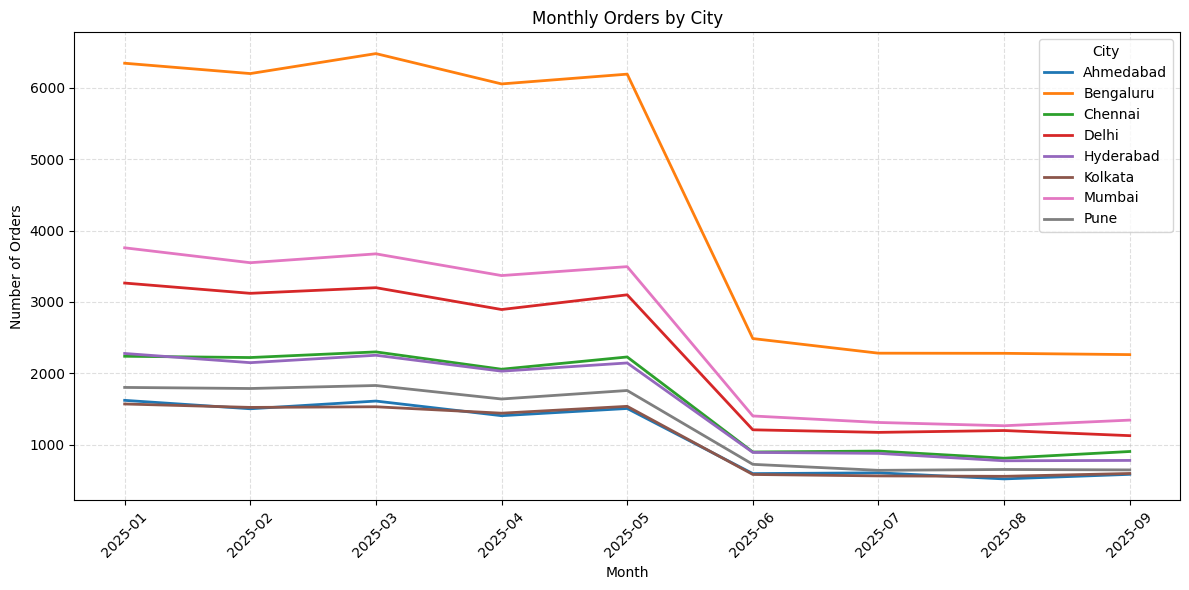

In [81]:
plt.figure(figsize=(12,6))
sns.lineplot(data=city_monthly_orders, 
             x=city_monthly_orders['Month'].astype(str), 
             y='Number of Orders', 
             hue='City',  
             linewidth=2)
plt.title("Monthly Orders by City")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [82]:
# Merge delivery performance with orders
delivery_orders = orders.merge(del_performance, on='order_id', how='left') # Merge delivery performance data with orders to analyze how delivery metrics impact order outcomes and customer satisfaction.
delivery_orders.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled,is_cancelled_flag,order_month,actual_delivery_time_mins,expected_delivery_time_mins,distance_km
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N,0,2025-01,31,31,6.4
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N,0,2025-01,46,42,1.9
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N,0,2025-01,25,31,6.2
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N,0,2025-01,29,41,6.2
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N,0,2025-01,37,41,2.4


In [83]:
monthly_delivery_time = (
    delivery_orders.groupby(
        delivery_orders['order_timestamp'].dt.to_period('M')
        )['actual_delivery_time_mins'].mean()
)

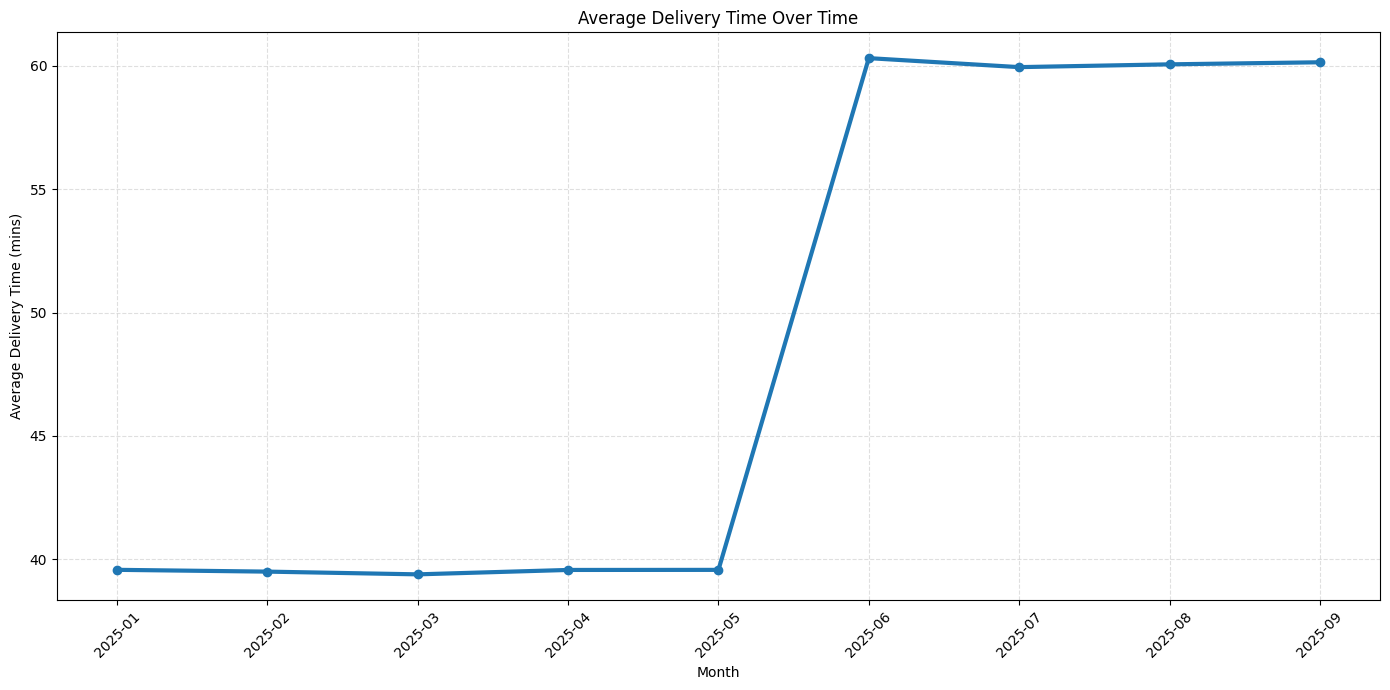

In [84]:
plt.figure(figsize=(14,7))

plt.plot(
    monthly_delivery_time.index.astype(str),
    monthly_delivery_time.values,
    linewidth=3,
    marker='o'
)

plt.title(
    "Average Delivery Time Over Time"
)

plt.xlabel("Month")
plt.ylabel("Average Delivery Time (mins)")

plt.xticks(rotation=45)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [85]:
delivery_orders['delivery_delay'] = (
    delivery_orders['actual_delivery_time_mins']
    - delivery_orders['expected_delivery_time_mins']
)

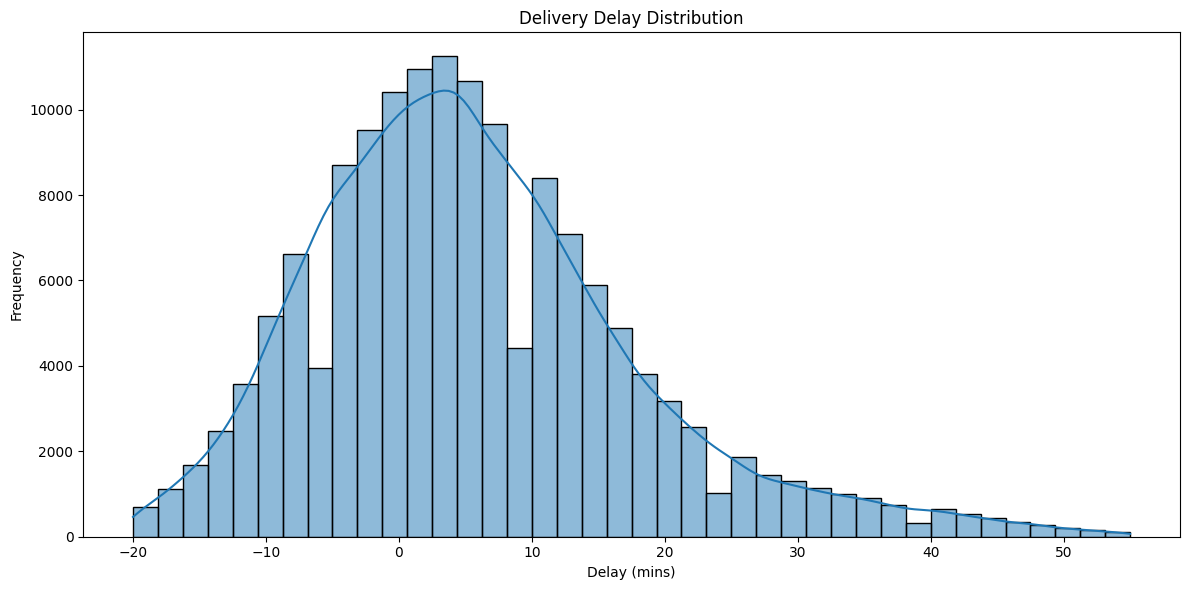

In [86]:
plt.figure(figsize=(12,6))

sns.histplot(
    delivery_orders['delivery_delay'],
    bins=40,
    kde=True
)

plt.title(
    "Delivery Delay Distribution"
)

plt.xlabel("Delay (mins)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [87]:
delivery_orders['sla_breach'] = (
    delivery_orders['delivery_delay'] > 0
).astype(int)

In [88]:
sla_breach_rate = (
    delivery_orders['sla_breach']
    .mean()
    * 100
)

print(f"SLA Breach Rate: {sla_breach_rate:.2f}%")

SLA Breach Rate: 63.84%


In [89]:
monthly_sla_breach = (
    delivery_orders.groupby(
        delivery_orders['order_timestamp'].dt.to_period('M')
    )['sla_breach']
    .mean()
    * 100
)

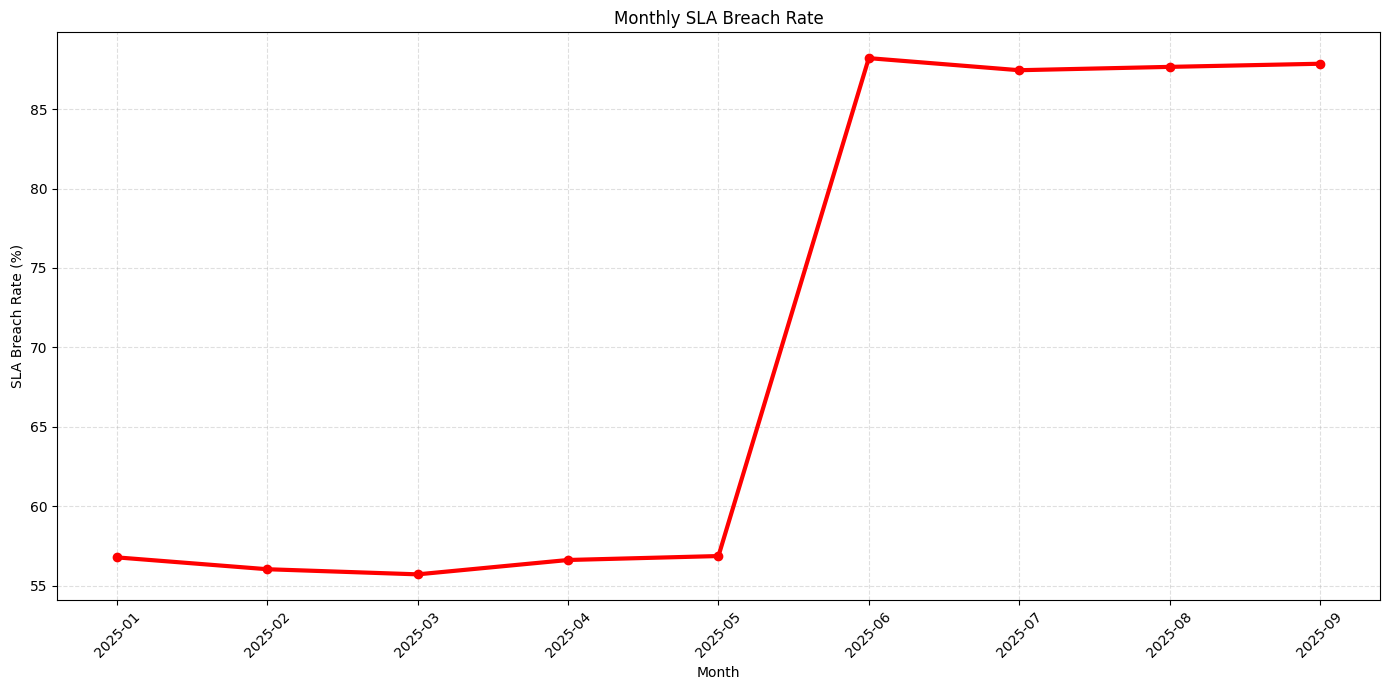

In [90]:
plt.figure(figsize=(14,7))

plt.plot(
    monthly_sla_breach.index.astype(str),
    monthly_sla_breach.values,
    linewidth=3,
    marker='o',
    color='red'
)

plt.title(
    "Monthly SLA Breach Rate"
)

plt.xlabel("Month")
plt.ylabel("SLA Breach Rate (%)")

plt.xticks(rotation=45)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [91]:
# Merge restaurant details into orders

orders_restaurants = (
    orders.merge(
        restaurants,
        on='restaurant_id',
        how='left'
    )
)
orders_restaurants.head()

,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled,is_cancelled_flag,order_month,restaurant_name,city,cuisine_type,partner_type,avg_prep_time_min,is_active
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N,0,2025-01,Spicy Wraps Point,Mumbai,North Indian,Restaurant,16-25,Y
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N,0,2025-01,Namma Mess Delight,Mumbai,Healthy,Restaurant,26-40,Y
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N,0,2025-01,Royal Biryani Darbar,Ahmedabad,Fast Food,Restaurant,16-25,Y
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N,0,2025-01,Delhi Express Palace,Ahmedabad,Pizza,Cloud Kitchen,16-25,Y
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N,0,2025-01,Flavours of Sweets Palace,Bengaluru,Chinese,Restaurant,26-40,N


In [92]:
top_restaurants = (
    orders_restaurants.groupby('restaurant_name')
    ['total_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

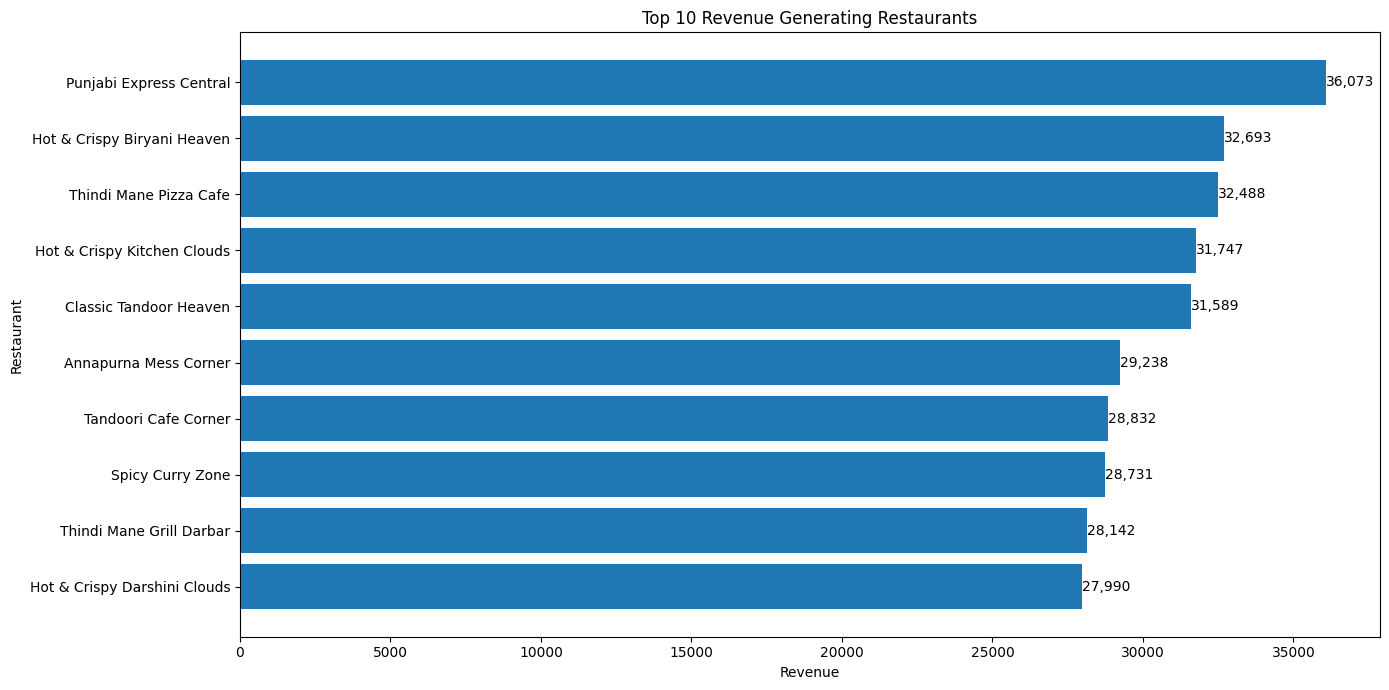

In [93]:
plt.figure(figsize=(14,7))

bars = plt.barh(
    top_restaurants.index,
    top_restaurants.values
)

plt.title(
    "Top 10 Revenue Generating Restaurants"
)

plt.xlabel("Revenue")
plt.ylabel("Restaurant")

# Highest at top
plt.gca().invert_yaxis()

# Revenue labels
for bar in bars:
    
    width = bar.get_width()
    
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center'
    )

plt.tight_layout()

plt.show()

In [94]:
restaurant_type_revenue = (
    orders_restaurants.groupby('partner_type')
    ['total_amount']
    .sum()
    .sort_values(ascending=False)
)

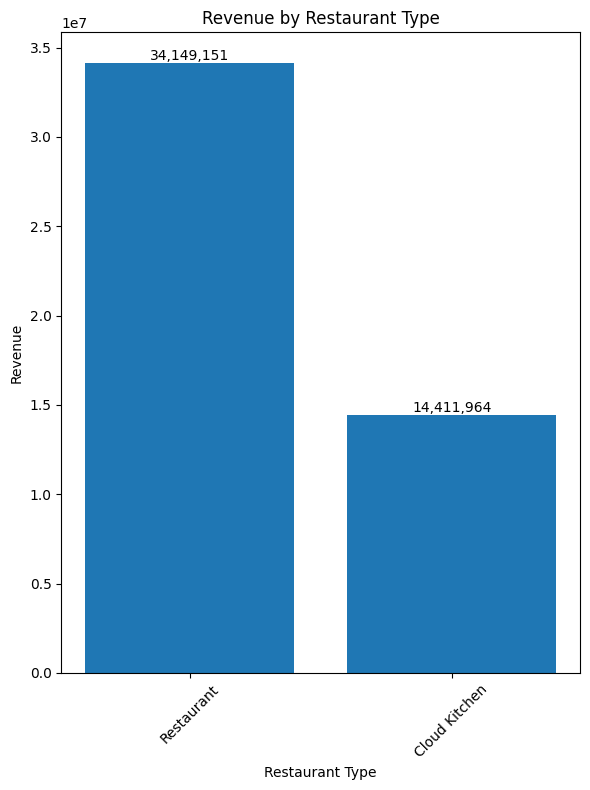

In [95]:
plt.figure(figsize=(6,8))

bars = plt.bar(
    restaurant_type_revenue.index,
    restaurant_type_revenue.values
)

plt.title(
    "Revenue by Restaurant Type"
)

plt.xlabel("Restaurant Type")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

# Revenue labels
for bar in bars:
    
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.show()

In [96]:
restaurant_cancellation = (
    orders_restaurants.groupby('restaurant_name')
    ['is_cancelled_flag']
    .mean()
    * 100
).sort_values(ascending=False).head(10)

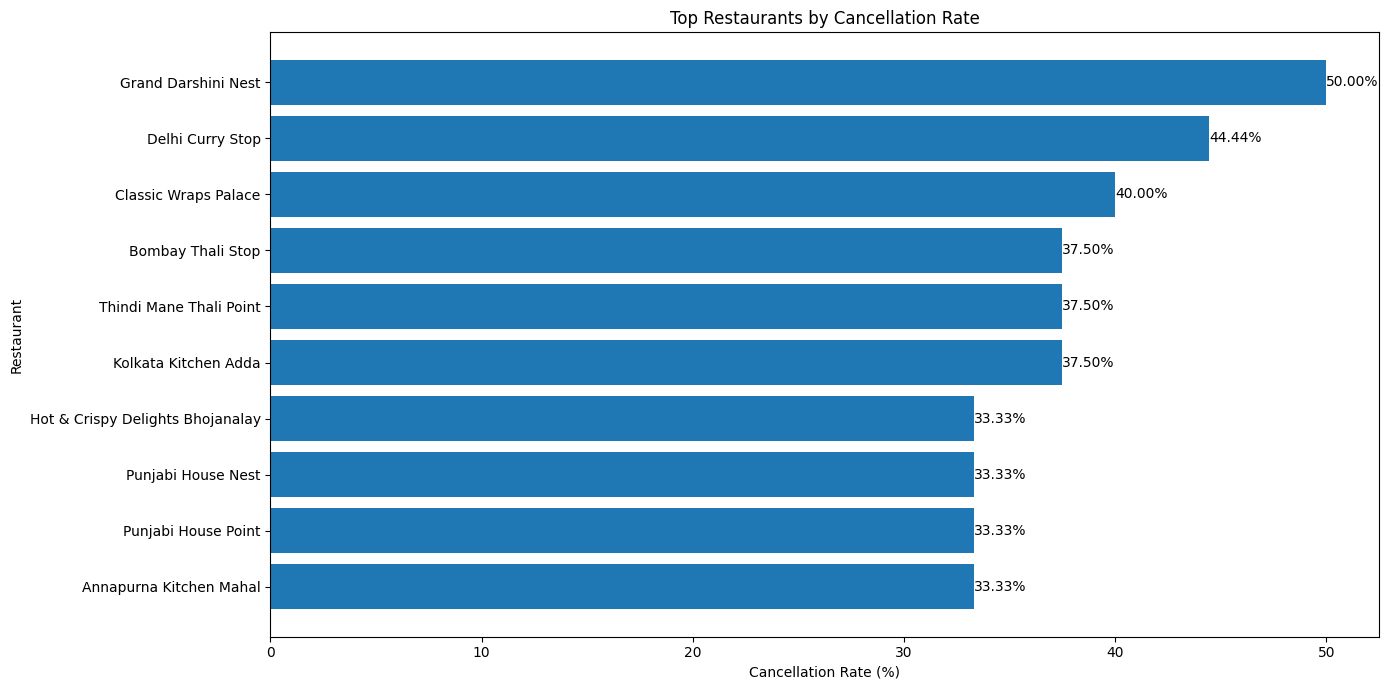

In [97]:
plt.figure(figsize=(14,7))

bars = plt.barh(
    restaurant_cancellation.index,
    restaurant_cancellation.values
)

plt.title(
    "Top Restaurants by Cancellation Rate"
)

plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Restaurant")

plt.gca().invert_yaxis()

# Percentage labels
for bar in bars:
    
    width = bar.get_width()
    
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}%',
        va='center'
    )

plt.tight_layout()

plt.show()

In [98]:
# Merge ratings with orders

ratings_orders = (
    ratings.merge(
        orders[
            [
                'order_id',
                'order_timestamp',
                'is_cancelled_flag'
            ]
        ],
        on='order_id',
        how='left'
    )
)
ratings_orders.head()

,order_id,customer_id,restaurant_id,rating,review_text,review_timestamp,sentiment_score,order_timestamp,is_cancelled_flag
0,ORD202501023439,CUST181110,REST08622,4.5,Super fast delivery,01-01-2025 15:00,0.75,2025-01-01 12:00:00,0
1,ORD202501019281,CUST179306,REST14069,4.5,Great taste!,01-01-2025 15:00,0.75,2025-01-01 12:00:00,0
2,ORD202501018036,CUST093042,REST13907,5.0,Super fast delivery,01-01-2025 14:03,1.00,2025-01-01 12:03:00,0
3,ORD202501007724,CUST110825,REST08451,4.0,Tasty but a bit late,01-01-2025 14:06,0.50,2025-01-01 12:06:00,0
4,ORD202501002349,CUST181669,REST00225,4.4,Satisfied overall,01-01-2025 14:06,0.70,2025-01-01 12:06:00,0


In [99]:
monthly_ratings = (
    ratings_orders.groupby(
        ratings_orders['order_timestamp'].dt.to_period('M')
    )['rating']
    .mean()
)

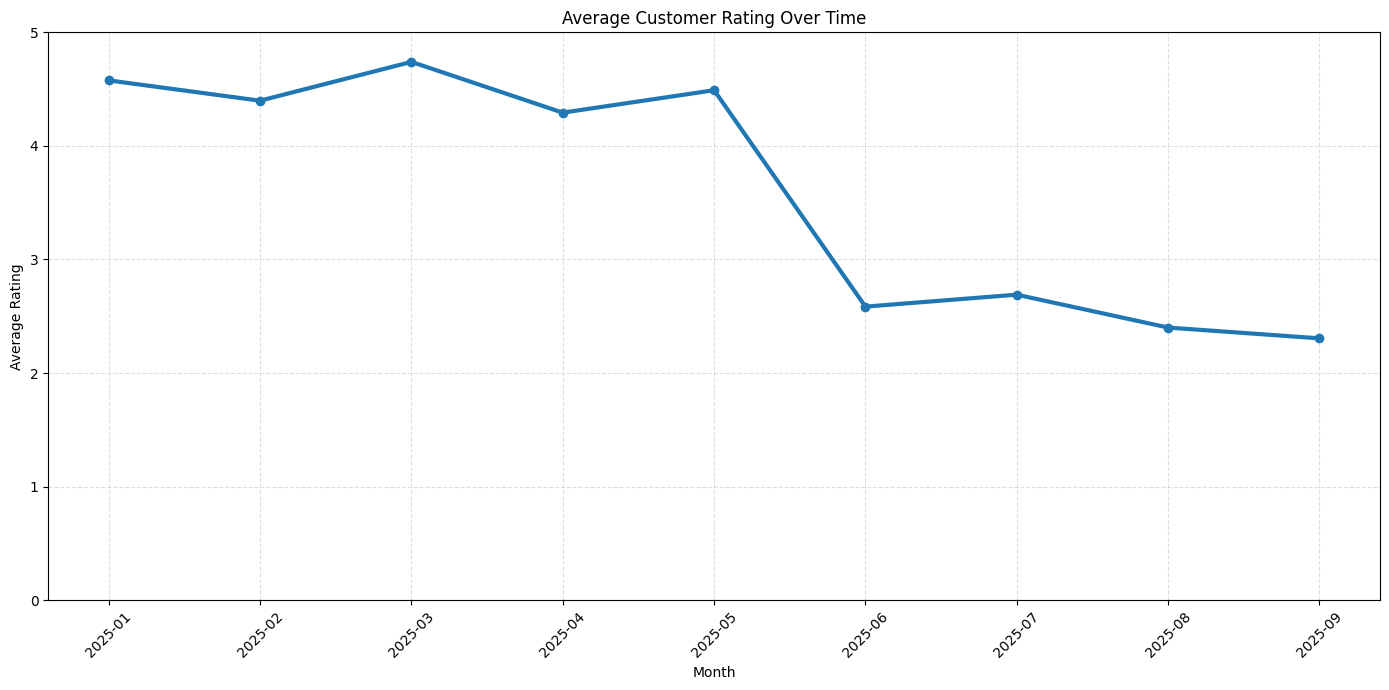

In [100]:
plt.figure(figsize=(14,7))

plt.plot(
    monthly_ratings.index.astype(str),
    monthly_ratings.values,
    linewidth=3,
    marker='o'
)

plt.title(
    "Average Customer Rating Over Time"
)

plt.xlabel("Month")
plt.ylabel("Average Rating")

plt.ylim(0,5)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [101]:
monthly_sentiment = (
    ratings_orders.groupby(
        ratings_orders['order_timestamp'].dt.to_period('M')
    )['sentiment_score']
    .mean()
)

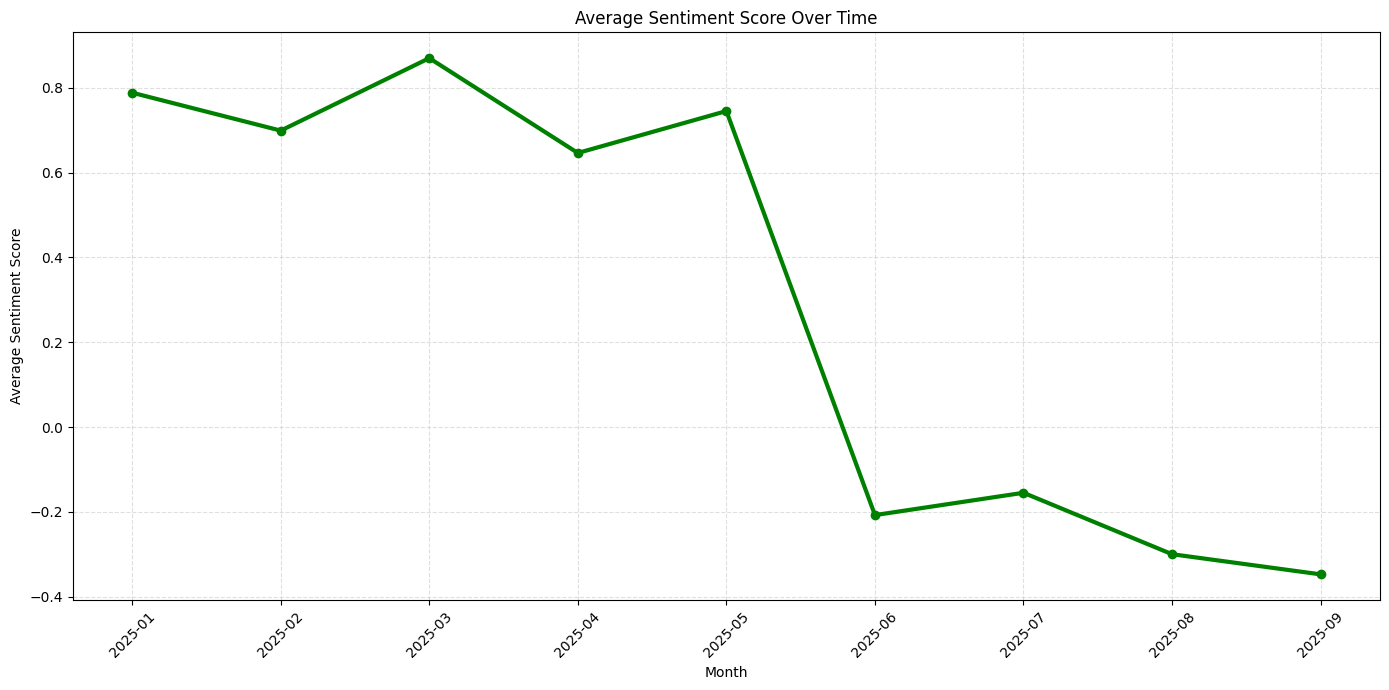

In [102]:
plt.figure(figsize=(14,7))

plt.plot(
    monthly_sentiment.index.astype(str),
    monthly_sentiment.values,
    linewidth=3,
    marker='o',
    color='green'
)

plt.title(
    "Average Sentiment Score Over Time"
)

plt.xlabel("Month")
plt.ylabel("Average Sentiment Score")

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

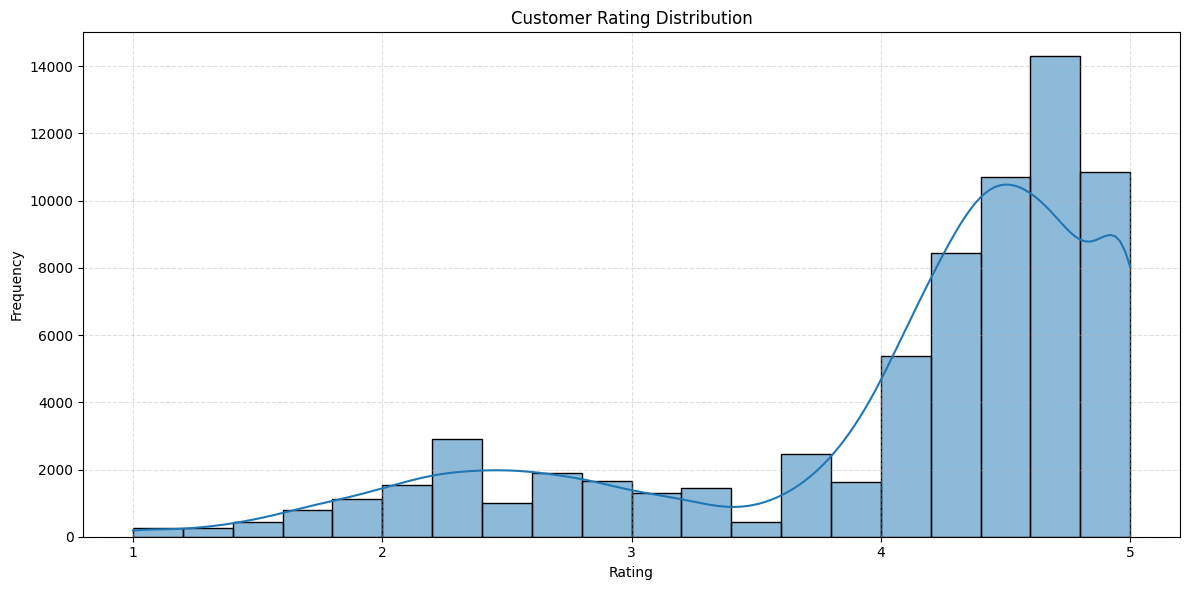

In [103]:
plt.figure(figsize=(12,6))

sns.histplot(
    ratings_orders['rating'],
    bins=20,
    kde=True
)

plt.title(
    "Customer Rating Distribution"
)

plt.xlabel("Rating")
plt.ylabel("Frequency")

# Cleaner x-axis ticks
plt.xticks(
    [1, 2, 3, 4, 5]
)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

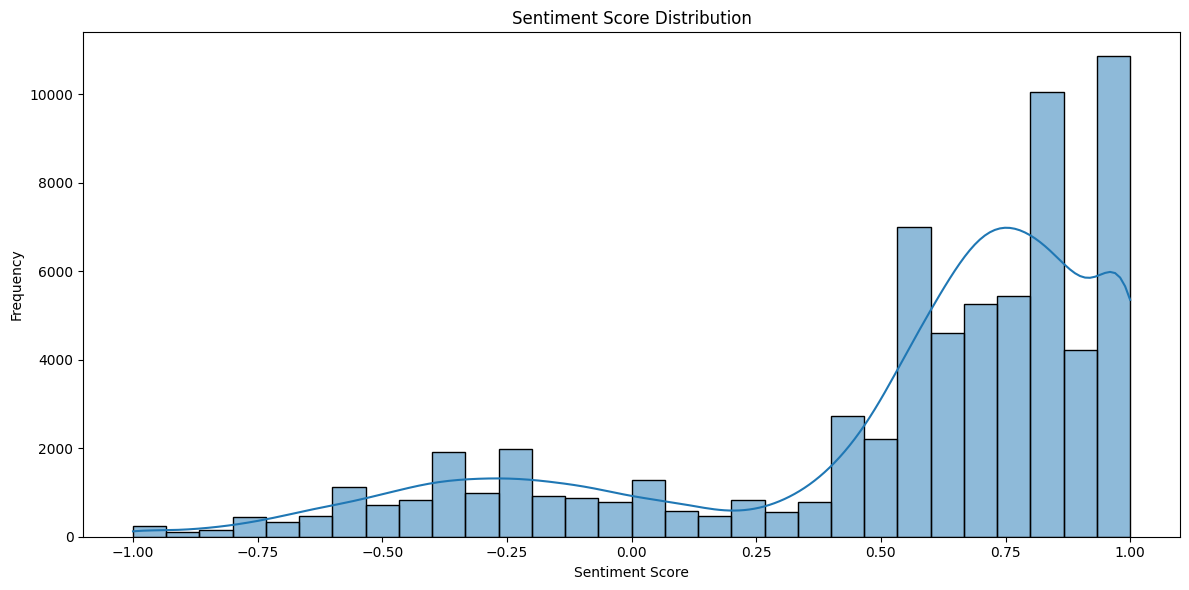

In [104]:
plt.figure(figsize=(12,6))

sns.histplot(
    ratings_orders['sentiment_score'],
    bins=30,
    kde=True
)

plt.title(
    "Sentiment Score Distribution"
)

plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [105]:
rating_vs_cancel = (
    ratings_orders.groupby('is_cancelled_flag')
    ['rating']
    .mean()
)

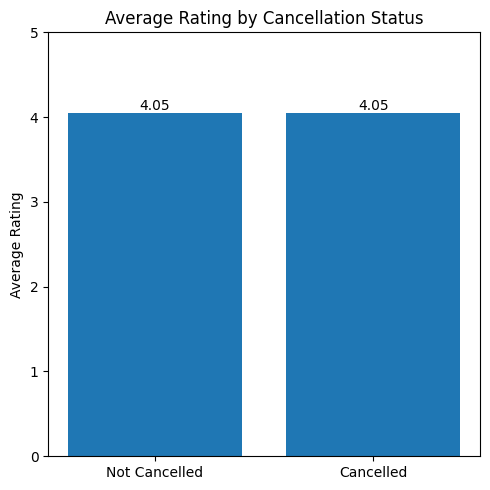

In [106]:
plt.figure(figsize=(5,5))

bars = plt.bar(
    ['Not Cancelled', 'Cancelled'],
    rating_vs_cancel.values
)

plt.title(
    "Average Rating by Cancellation Status"
)

plt.ylabel("Average Rating")

# Labels
for bar in bars:
    
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.ylim(0,5)

plt.tight_layout()

plt.show()

# Statistical Tests

### Crisis vs Pre-Crisis Delivery Time (T-Test)

In [107]:
delivery_orders['order_date'] = pd.to_datetime(
    delivery_orders['order_timestamp']
    ) # Extract order date from order_timestamp to analyze daily delivery performance trends and their impact on customer satisfaction
delivery_orders['phase'] = np.where(
    delivery_orders['order_date'] < '2025-05-15',
    'Pre-Crisis',
    'Crisis'
) # Create a phase column to classify orders as pre-crisis or post-crisis based on the order date, allowing for analysis of how delivery performance and customer satisfaction may have changed due to the crisis.

In [108]:
pre_crisis = delivery_orders[
    delivery_orders['phase'] == 'Pre-Crisis'
    ]['actual_delivery_time_mins'] # Filter delivery orders for the pre-crisis phase to analyze delivery performance and customer satisfaction before the crisis.
crisis = delivery_orders[
    delivery_orders['phase'] == 'Crisis'
    ]['actual_delivery_time_mins'] # Filter delivery orders for the crisis phase to analyze delivery performance and customer satisfaction during the crisis.

In [109]:
t_stat, p_value = ttest_ind(
    pre_crisis,
    crisis,
    equal_var=False
)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")

T-statistic: -208.31, P-value: 0.0000


In [110]:
print('Mean Pre-Crisis Delivery Time:', pre_crisis.mean().__round__(2))
print('Mean Crisis Delivery Time:', crisis.mean().__round__(2))

Mean Pre-Crisis Delivery Time: 39.52
Mean Crisis Delivery Time: 54.79


#### Test Interpretation:
* P-value = 0.0000 i.e p-value < 0.05 
* So:
    * the result is statistically significant.
    * We can **reject the null hypothesis.**
* Delivery times changed significantly during the crisis.
* Very Large T-Statistic Magnitude :
    * **-208.31** This is extremely large.
    * It indicates:
    * **a very strong difference between groups.**
* The T-Statistics Magnitude is negative because the crisis delivery times were higher.
* **Mean Pre-Crisis Delivery Time: 39.52**
* **Mean Crisis Delivery Time: 54.79**
* So, **pre_crisis_mean < crisis_mean**, which supports delivery performance worsened during crisis.

### Ratings Across Phases (T-Test)

In [111]:
ratings_orders['phase'] = np.where(
    ratings_orders['order_timestamp'] < '2025-05-15',
    'Pre-Crisis',
    'Crisis'
)

In [112]:
pre_ratings = ratings_orders[
    ratings_orders['phase'] == 'Pre-Crisis'
]['rating']

crisis_ratings = ratings_orders[
    ratings_orders['phase'] == 'Crisis'
]['rating']

In [113]:
t_stat, p_value = ttest_ind(
    pre_ratings,
    crisis_ratings,
    equal_var=False
)

print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_value:.4f}")

T-Statistic: 199.38
P-Value: 0.0000


In [114]:
ratings_orders.groupby('phase')['rating'].mean()

phase
Crisis        3.043708
Pre-Crisis    4.505978
Name: rating, dtype: float64

#### Test Interpretation :
* Ratings Dropped MASSIVELY
    * From:
    * **4.51 → 3.04**
    * That is a severe decline in customer satisfaction.
* P-value = 0.0000
    * So, as p-value < 0.05
    * We can **reject the null hypothesis.**
* There is a significant change in customer ratings between pre-crisis and crisis
* Large Positive T-Statistic
    * This indicates:
    * pre-crisis ratings were significantly higher than crisis ratings.

#### Delivery Delay vs Cancellation(Chi-Square Test)

In [115]:
delivery_orders['delayed'] = np.where(
    delivery_orders['delivery_delay'] > 0,
    'Delayed',
    'On-Time'
)

In [116]:
contingency_table = pd.crosstab(
    delivery_orders['delayed'],
    delivery_orders['is_cancelled_flag']
)

contingency_table

is_cancelled_flag,0,1
delayed,,
Delayed,87603,7623
On-Time,50451,3489


In [117]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-Value: {p_value:.4f}")

Chi-Square Statistic: 117.75
P-Value: 0.0000


In [118]:
delay_cancel_rate = (
    delivery_orders.groupby('delayed')
    ['is_cancelled_flag']
    .mean()
    * 100
)

delay_cancel_rate

delayed
Delayed    8.005167
On-Time    6.468298
Name: is_cancelled_flag, dtype: float64

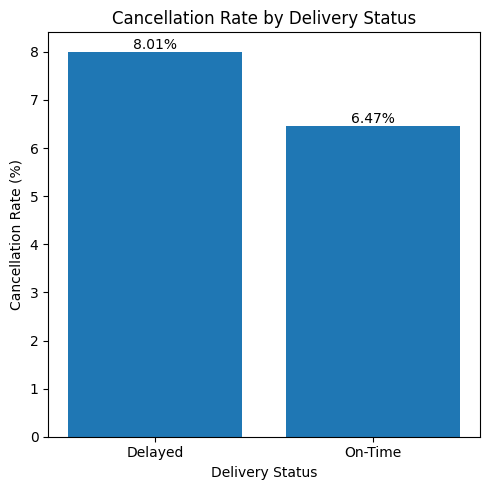

In [119]:
plt.figure(figsize=(5,5))

bars = plt.bar(
    delay_cancel_rate.index,
    delay_cancel_rate.values
)

plt.title(
    "Cancellation Rate by Delivery Status"
)

plt.xlabel("Delivery Status")
plt.ylabel("Cancellation Rate (%)")

# Callout labels
for bar in bars:
    
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.show()

#### Test Interpretation :
* P-value = 0.0000
    * Meaning: p < 0.05
    * So: **there is a statistically significant relationship**
    * between:
        * delivery delays and cancellations.
* This relationship is NOT random.

* Business Impact
    * Delayed orders have:
    * **higher cancellation rates.**
    * From:
        * **6.47% → 8.01%**
    * That’s a meaningful operational increase.

#### Correlation Analysis : Delivery Delay vs Ratings

In [120]:
delay_rating = (
    delivery_orders.merge(
        ratings[['order_id', 'rating']],
        on='order_id',
        how='inner'
    )
) # Merge delivery orders with ratings to analyze how delivery delays impact customer ratings and satisfaction.

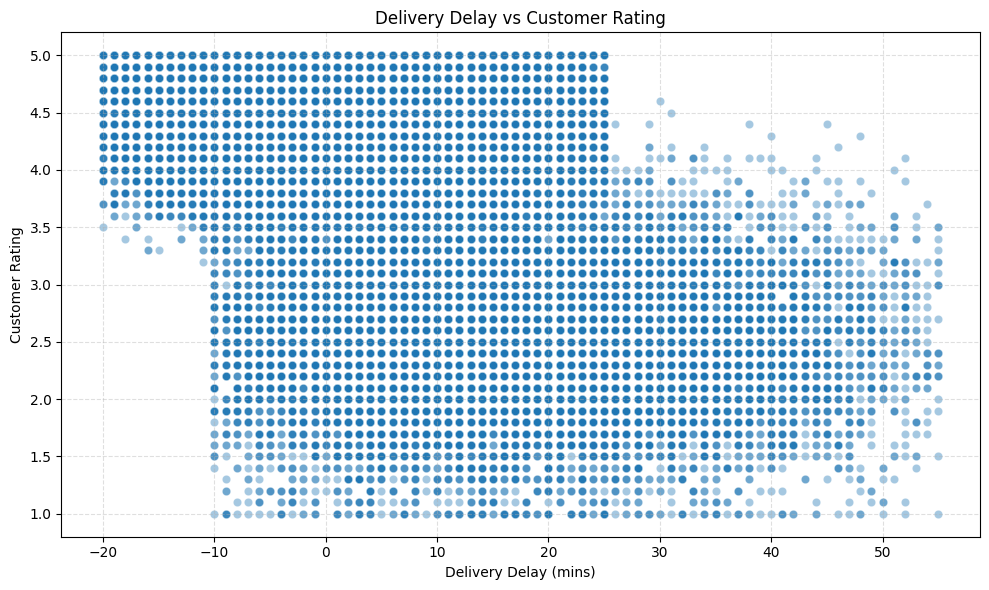

In [121]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=delay_rating,
    x='delivery_delay',
    y='rating',
    alpha=0.4
)

plt.title(
    "Delivery Delay vs Customer Rating"
)

plt.xlabel("Delivery Delay (mins)")
plt.ylabel("Customer Rating")

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [122]:
corr, p_value = spearmanr(
    delay_rating['delivery_delay'],
    delay_rating['rating']
)

print(f"Spearman Correlation: {corr:.4f}")
print(f"P-Value: {p_value:.4f}")

Spearman Correlation: -0.3256
P-Value: 0.0000


#### Test Interpretaion :
* We use the Spearman Correlation because the Scatter Plot shows :
    * non-linear behavior,
    * dense clustering,
    * rating bands,
    * possible monotonic trend instead of linear trend.
* Spearman Correlation :
    * handles monotonic relationships,
    * is robust to outliers,
    * works better with rating-type data,
    * fits business datasets better.

* We have a Negative Correlation **-0.3256** that means delivery delay increases, and customer ratings decrease.
* As the Correlation is below 0.5, So the Correlation Strength is **moderate negative relationship**.
*  P-value = 0.0000 :
    * So: the relationship is statistically significant
    

# Feature Engineering

## Customer Intelligence Dataset

In [123]:
# Total Orders per Customer
customer_features = (
    orders.groupby('customer_id')
    ['order_id']
    .count()
    .reset_index()
) # Group orders by customer to calculate total orders per customer, which can be used as a feature for analyzing customer behavior and segmentation.
customer_features.columns = ['customer_id', 'total_orders'] # Rename columns for clarity in customer features DataFrame
customer_features.head()

,customer_id,total_orders
0,CUST000007,1
1,CUST000008,1
2,CUST000009,4
3,CUST000010,3
4,CUST000011,1


In [124]:
# Total Spend per Customer
total_spend = (
    orders.groupby('customer_id')
    ['total_amount']
    .sum()
    .reset_index()
) # Group orders by customer to calculate total spend per customer, which can be used as a feature for analyzing customer behavior and segmentation.
total_spend.columns = ['customer_id', 'total_spend'] # Rename columns for clarity in total spend DataFrame
total_spend.head()

,customer_id,total_spend
0,CUST000007,239.39
1,CUST000008,246.05
2,CUST000009,983.82
3,CUST000010,652.08
4,CUST000011,146.56


In [125]:
customer_features = customer_features.merge(
    total_spend,
    on='customer_id',
    how='left'
) # Merge total spend into customer features to create a comprehensive dataset for analyzing customer behavior and segmentation.

In [126]:
# Average Order Value (AOV)
customer_features['avg_order_value'] = (
    customer_features['total_spend'] 
    / customer_features['total_orders']
 ) # Calculate average order value for each customer to analyze purchasing behavior and segment customers based on their spending patterns.

In [127]:
# Order Frequency
dataset_days = (
    orders['order_timestamp'].max() 
    - orders['order_timestamp'].min()
).days # Calculate the total number of days in the dataset to use for calculating order frequency, which can help analyze customer engagement and segment customers based on how frequently they order.
dataset_days

272

In [128]:
customer_features['order_frequency'] = (
    customer_features['total_orders']
    / dataset_days
) # Calculate order frequency for each customer to analyze engagement and segment customers based on how frequently they order.

In [129]:
# Customer Tenure
customer_features = customer_features.merge(
    customers[['customer_id', 'signup_date']],
    on='customer_id',
    how='left'
) # Merge signup date from customers dataset into customer features to calculate customer tenure, which can be used to analyze customer loyalty and segment customers based on how long they have been with the service.

In [130]:
customer_features['signup_date'] = pd.to_datetime(
    customer_features['signup_date']
    ) # Convert signup_date to datetime format for easier calculation of customer tenure.

In [131]:
latest_date = orders['order_timestamp'].max() # Get the latest order date in the dataset to use as a reference point for calculating customer tenure.
customer_features['customer_tenure_days'] = (
    latest_date - customer_features['signup_date']
).dt.days # Calculate customer tenure in days to analyze loyalty and segment customers based on how long they have been with the service.

In [132]:
# Days Since Last Order (Recency)
last_order = (
    orders.groupby('customer_id')['order_timestamp']
    .max()
    .reset_index()
) # Group orders by customer and get the most recent order timestamp to calculate days since last order, which can be used to analyze customer engagement and segment customers based on recency of their orders.
last_order.columns = ['customer_id', 'last_order_date'] # Rename columns for clarity in last order DataFrame

In [133]:
customer_features = customer_features.merge(
    last_order,
    on='customer_id',
    how='left'
) # Merge last order date into customer features to calculate days since last order, which can be used to analyze customer engagement and segment customers based on recency of their orders.

In [134]:
customer_features['days_since_last_order'] = (
    latest_date - customer_features['last_order_date']
).dt.days # Calculate days since last order to analyze customer engagement and segment customers based on recency of their orders.

In [135]:
# Customer Cancellation Rate
customer_cancel_rate = (
    orders.groupby('customer_id')['is_cancelled_flag']
    .mean()
    .reset_index()  
)   # Group orders by customer and calculate cancellation rate to analyze customer behavior and segment customers based on their likelihood to cancel orders.
customer_cancel_rate.columns = ['customer_id', 'customer_cancel_rate'] # Rename columns for clarity

In [136]:
customer_cancel_rate['customer_cancel_rate'] *= 100 # Convert cancellation rate to percentage for easier interpretation and analysis.

In [137]:
customer_features = customer_features.merge(
    customer_cancel_rate,
    on='customer_id',
    how='left'
) # Merge customer cancellation rate into customer features to create a comprehensive dataset for analyzing customer behavior and segmentation.

## Final Customer Behavioral Feature Table

In [138]:
customer_features

,customer_id,total_orders,total_spend,avg_order_value,order_frequency,signup_date,customer_tenure_days,last_order_date,days_since_last_order,customer_cancel_rate
0,CUST000007,1,239.39,239.390,0.003676,2025-03-21,193.0,2025-05-11 12:39:00,142,0.0
1,CUST000008,1,246.05,246.050,0.003676,2025-02-07,235.0,2025-02-17 21:30:00,225,0.0
2,CUST000009,4,983.82,245.955,0.014706,2025-02-25,217.0,2025-08-08 20:47:00,53,25.0
3,CUST000010,3,652.08,217.360,0.011029,2025-01-28,245.0,2025-05-24 12:43:00,129,0.0
4,CUST000011,1,146.56,146.560,0.003676,2025-01-18,255.0,2025-02-09 22:41:00,233,0.0
...,...,...,...,...,...,...,...,...,...,...
105175,CUST199995,1,216.68,216.680,0.003676,2024-11-19,315.0,2025-01-08 21:26:00,265,0.0
105176,CUST199996,1,366.30,366.300,0.003676,2025-01-14,259.0,2025-01-28 20:49:00,245,0.0
105177,CUST199997,1,556.69,556.690,0.003676,2024-12-22,282.0,2025-01-04 22:49:00,269,0.0
105178,CUST199999,1,334.26,334.260,0.003676,2025-05-11,142.0,2025-05-13 19:01:00,140,0.0


## Delivery Intelligence Features

In [139]:
# Average Delivery Delay per Customer
customer_delay = (
    delivery_orders.groupby('customer_id')['delivery_delay']
    .mean()
    .reset_index()
) # Group delivery orders by customer and calculate average delivery delay to analyze how delivery performance impacts customer behavior and segment customers based on their experience with delivery delays.
customer_delay.columns = ['customer_id', 'avg_delivery_delay'] # Rename columns for clarity

In [140]:
customer_features = customer_features.merge(
    customer_delay,
    on='customer_id',
    how='left'
) # Merge average delivery delay into customer features to create a comprehensive dataset for analyzing customer behavior and segmentation based on delivery performance.

In [141]:
# Average Actual Delivery Time
avg_delivery_time = (
    delivery_orders.groupby('customer_id')['actual_delivery_time_mins']
    .mean()
    .reset_index()
) # Group delivery orders by customer and calculate average actual delivery time to analyze how delivery performance impacts customer behavior and segment customers based on their experience with delivery times.
avg_delivery_time.columns = ['customer_id', 'avg_actual_delivery_time'] # Rename columns for clarity

In [142]:
customer_features = customer_features.merge(
    avg_delivery_time,
    on='customer_id',
    how='left'
) # Merge average actual delivery time into customer features to create a comprehensive dataset for analyzing customer behavior and segmentation based on delivery performance.

In [143]:
# SLA Breach Rate
customer_sla_breach = (
    delivery_orders.groupby('customer_id')
    ['sla_breach']
    .mean()
    .reset_index()
) # Group delivery orders by customer and calculate SLA breach rate to analyze how delivery performance impacts customer behavior and segment customers based on their experience with SLA breaches.

customer_sla_breach.columns = [
    'customer_id',
    'sla_breach_rate'
] # Rename columns for clarity

In [144]:
customer_sla_breach['sla_breach_rate'] *= 100 # Convert SLA breach rate to percentage for easier interpretation and analysis.

In [145]:
customer_features = customer_features.merge(
    customer_sla_breach,
    on='customer_id',
    how='left'
) # Merge SLA breach rate into customer features to create a comprehensive dataset for analyzing customer behavior and segmentation based on delivery performance and SLA breaches.

In [146]:
# Severe Delay Count
delivery_orders['severe_delay'] = np.where(
    delivery_orders['delivery_delay'] > 20,
    1,
    0
) # Create a binary flag for severe delivery delays (greater than 20 minutes) to analyze how extreme delivery issues impact customer behavior and segment customers based on their experience with severe delays.

In [147]:
severe_delay_count = (
    delivery_orders.groupby('customer_id')
    ['severe_delay']
    .sum()
    .reset_index()
) # Group delivery orders by customer and calculate the count of severe delays to analyze how extreme delivery issues impact customer behavior and segment customers based on their experience with severe delays.

severe_delay_count.columns = [
    'customer_id',
    'severe_delay_count'
]

In [148]:
customer_features = customer_features.merge(
    severe_delay_count,
    on='customer_id',
    how='left'
)

In [149]:
# Average Delivery Distance
avg_distance = (
    delivery_orders.groupby('customer_id')
    ['distance_km']
    .mean()
    .reset_index()
) # Group delivery orders by customer and calculate average delivery distance to analyze how delivery distance impacts customer behavior and segment customers based on their experience with delivery distances.

avg_distance.columns = [
    'customer_id',
    'avg_delivery_distance'
] # Rename columns for clarity

In [150]:
customer_features = customer_features.merge(
    avg_distance,
    on='customer_id',
    how='left'
)

## Final Customer Behavioral Feature Table updated with Delivery features

In [151]:
customer_features.head()

,customer_id,total_orders,total_spend,avg_order_value,order_frequency,signup_date,customer_tenure_days,last_order_date,days_since_last_order,customer_cancel_rate,avg_delivery_delay,avg_actual_delivery_time,sla_breach_rate,severe_delay_count,avg_delivery_distance
0,CUST000007,1,239.39,239.390,0.003676,2025-03-21,193.0,2025-05-11 12:39:00,142,0.0,12.000000,47.0,100.0,0,2.100000
1,CUST000008,1,246.05,246.050,0.003676,2025-02-07,235.0,2025-02-17 21:30:00,225,0.0,-2.000000,28.0,0.0,0,2.500000
2,CUST000009,4,983.82,245.955,0.014706,2025-02-25,217.0,2025-08-08 20:47:00,53,25.0,5.250000,50.5,75.0,1,2.800000
3,CUST000010,3,652.08,217.360,0.011029,2025-01-28,245.0,2025-05-24 12:43:00,129,0.0,5.666667,46.0,100.0,0,3.333333
4,CUST000011,1,146.56,146.560,0.003676,2025-01-18,255.0,2025-02-09 22:41:00,233,0.0,1.000000,45.0,100.0,0,6.100000


## Customer Satisfaction Features

In [152]:
# Average Rating per Customer
customer_rating = (
    ratings.groupby('customer_id')
    ['rating']
    .mean()
    .reset_index()
) # Group ratings by customer and calculate average rating to analyze customer satisfaction and segment customers based on their average ratings.

customer_rating.columns = [
    'customer_id',
    'avg_rating'
]

In [153]:
customer_features = customer_features.merge(
    customer_rating,
    on='customer_id',
    how='left'
)

In [154]:
# Average Sentiment Score
customer_sentiment = (
    ratings.groupby('customer_id')
    ['sentiment_score']
    .mean()
    .reset_index()
) # Group ratings by customer and calculate average sentiment score to analyze customer sentiment and segment customers based on their average sentiment scores.

customer_sentiment.columns = [
    'customer_id',
    'avg_sentiment_score'
]

In [155]:
customer_features = customer_features.merge(
    customer_sentiment,
    on='customer_id',
    how='left'
)

In [156]:
# Negative Review Count (rating < 3)
ratings['negative_review'] = np.where(
    ratings['rating'] < 3,
    1,
    0
)

In [157]:
negative_reviews = (
    ratings.groupby('customer_id')
    ['negative_review']
    .sum()
    .reset_index()
) # Group ratings by customer and calculate the count of negative reviews (ratings less than 3) to analyze customer dissatisfaction and segment customers based on their experience with negative reviews.

negative_reviews.columns = [
    'customer_id',
    'negative_review_count'
]

In [158]:
customer_features = customer_features.merge(
    negative_reviews,
    on='customer_id',
    how='left'
)

In [159]:
# Total Reviews
total_reviews = (
    ratings.groupby('customer_id')
    ['review_text']
    .count()
    .reset_index()
) # Group ratings by customer and count the total number of reviews to analyze customer engagement and segment customers based on their review activity.

total_reviews.columns = [
    'customer_id',
    'total_reviews'
]

In [160]:
customer_features = customer_features.merge(
    total_reviews,
    on='customer_id',
    how='left'
)

In [161]:
# Negative Review Rate
customer_features['negative_review_rate'] = (
    customer_features['negative_review_count']
    / customer_features['total_reviews']
)

In [162]:
customer_features['negative_review_rate'] *= 100

#### Handle Missing Values (Some customers may never review.)

In [163]:
review_cols = [
    'avg_rating',
    'avg_sentiment_score',
    'negative_review_count',
    'total_reviews',
    'negative_review_rate'
]

customer_features[review_cols] = (
    customer_features[review_cols]
    .fillna(0)
) # Fill NaN values in review-related columns with 0 to handle customers who have not left any reviews, ensuring that the dataset is complete for analysis and modeling.

## Final Customer Behavioral Feature Table updated with Delivery features, Rating features

In [164]:
customer_features.head()

,customer_id,total_orders,total_spend,avg_order_value,order_frequency,signup_date,customer_tenure_days,last_order_date,days_since_last_order,customer_cancel_rate,avg_delivery_delay,avg_actual_delivery_time,sla_breach_rate,severe_delay_count,avg_delivery_distance,avg_rating,avg_sentiment_score,negative_review_count,total_reviews,negative_review_rate
0,CUST000007,1,239.39,239.390,0.003676,2025-03-21,193.0,2025-05-11 12:39:00,142,0.0,12.000000,47.0,100.0,0,2.100000,5.0,1.00,0.0,1.0,0.0
1,CUST000008,1,246.05,246.050,0.003676,2025-02-07,235.0,2025-02-17 21:30:00,225,0.0,-2.000000,28.0,0.0,0,2.500000,0.0,0.00,0.0,0.0,0.0
2,CUST000009,4,983.82,245.955,0.014706,2025-02-25,217.0,2025-08-08 20:47:00,53,25.0,5.250000,50.5,75.0,1,2.800000,0.0,0.00,0.0,0.0,0.0
3,CUST000010,3,652.08,217.360,0.011029,2025-01-28,245.0,2025-05-24 12:43:00,129,0.0,5.666667,46.0,100.0,0,3.333333,4.1,0.55,0.0,2.0,0.0
4,CUST000011,1,146.56,146.560,0.003676,2025-01-18,255.0,2025-02-09 22:41:00,233,0.0,1.000000,45.0,100.0,0,6.100000,0.0,0.00,0.0,0.0,0.0


# Restaurant Interaction Features

In [165]:
#Unique Restaurants Ordered
unique_restaurants = (
    orders.groupby('customer_id')
    ['restaurant_id']
    .nunique()
    .reset_index()
)

unique_restaurants.columns = [
    'customer_id',
    'unique_restaurants'
]

In [166]:
customer_features = customer_features.merge(
    unique_restaurants,
    on='customer_id',
    how='left'
)

In [167]:
# Favorite Restaurant Order Count
favorite_restaurant = (
    orders.groupby(
        ['customer_id', 'restaurant_id']
    )['order_id']
    .count()
    .reset_index()
)

In [168]:
favorite_restaurant_count = (
    favorite_restaurant.groupby('customer_id')
    ['order_id']
    .max()
    .reset_index()
)

favorite_restaurant_count.columns = [
    'customer_id',
    'favorite_restaurant_orders'
]

In [169]:
customer_features = customer_features.merge(
    favorite_restaurant_count,
    on='customer_id',
    how='left'
)

In [170]:
# Favorite Restaurant Ratio
customer_features['favorite_restaurant_ratio'] = (
    customer_features['favorite_restaurant_orders']
    / customer_features['total_orders']
) * 100

In [171]:
restaurants['avg_prep_time_min'].head()

0    26-40
1    16-25
2    16-25
3    16-25
4    26-40
Name: avg_prep_time_min, dtype: str

In [172]:
# Convert Ranges to Numeric Midpoints
def range_to_midpoint(x):
    
    # Handle missing values
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    # Handle normal ranges
    if '-' in x:
        
        low, high = x.split('-')
        
        return (
            int(low) + int(high)
        ) / 2

    # Handle single values like "30"
    elif x.isdigit():
        
        return float(x)

    # Handle "40+" format
    elif '+' in x:
        
        return float(
            x.replace('+', '')
        )

    # Unknown formats
    else:
        return np.nan

In [173]:
# Apply Conversion
restaurants['midpoint_prep_time_min'] = (
    restaurants['avg_prep_time_min']
    .apply(range_to_midpoint)
)

In [174]:
restaurants[
    ['avg_prep_time_min', 'midpoint_prep_time_min']
].head(10)

,avg_prep_time_min,midpoint_prep_time_min
0,26-40,33.0
1,16-25,20.5
2,16-25,20.5
3,16-25,20.5
4,26-40,33.0
5,26-40,33.0
6,16-25,20.5
7,26-40,33.0
8,16-25,20.5
9,>40,NaN


In [175]:
# Average Restaurant Prep Time Experienced
orders_restaurants = (
    orders.merge(
        restaurants[
            ['restaurant_id', 'midpoint_prep_time_min']
        ],
        on='restaurant_id',
        how='left'
    )
)

In [176]:
customer_prep_time = (
    orders_restaurants.groupby('customer_id')
    ['midpoint_prep_time_min']
    .mean()
    .reset_index()
)

customer_prep_time.columns = [
    'customer_id',
    'avg_restaurant_prep_time_experienced'
]

In [177]:
customer_features = customer_features.merge(
    customer_prep_time,
    on='customer_id',
    how='left'
)

In [178]:
customer_features['avg_restaurant_prep_time_experienced'].isna().sum()

np.int64(28385)

In [179]:
median_prep_time = (
    customer_features[
        'avg_restaurant_prep_time_experienced'
    ]
    .median()
)

In [180]:
customer_features[
    'avg_restaurant_prep_time_experienced'
] = (
    customer_features[
        'avg_restaurant_prep_time_experienced'
    ]
    .fillna(median_prep_time)
)

In [181]:
customer_features[
    'avg_restaurant_prep_time_experienced'
].isna().sum()

np.int64(0)

In [182]:
customer_features.head()

,customer_id,total_orders,total_spend,avg_order_value,order_frequency,signup_date,customer_tenure_days,last_order_date,days_since_last_order,customer_cancel_rate,...,avg_delivery_distance,avg_rating,avg_sentiment_score,negative_review_count,total_reviews,negative_review_rate,unique_restaurants,favorite_restaurant_orders,favorite_restaurant_ratio,avg_restaurant_prep_time_experienced
0,CUST000007,1,239.39,239.390,0.003676,2025-03-21,193.0,2025-05-11 12:39:00,142,0.0,...,2.100000,5.0,1.00,0.0,1.0,0.0,1,1,100.000000,20.50
1,CUST000008,1,246.05,246.050,0.003676,2025-02-07,235.0,2025-02-17 21:30:00,225,0.0,...,2.500000,0.0,0.00,0.0,0.0,0.0,1,1,100.000000,20.50
2,CUST000009,4,983.82,245.955,0.014706,2025-02-25,217.0,2025-08-08 20:47:00,53,25.0,...,2.800000,0.0,0.00,0.0,0.0,0.0,4,1,25.000000,26.75
3,CUST000010,3,652.08,217.360,0.011029,2025-01-28,245.0,2025-05-24 12:43:00,129,0.0,...,3.333333,4.1,0.55,0.0,2.0,0.0,3,1,33.333333,26.75
4,CUST000011,1,146.56,146.560,0.003676,2025-01-18,255.0,2025-02-09 22:41:00,233,0.0,...,6.100000,0.0,0.00,0.0,0.0,0.0,1,1,100.000000,33.00


# Time-Based Features + Crisis Features

In [183]:
# Extract Time Components
orders['order_hour'] = (
    orders['order_timestamp']
    .dt.hour
) # Extract hour from order_timestamp to analyze hourly ordering patterns and segment customers based on their preferred ordering times.

orders['order_day'] = (
    orders['order_timestamp']
    .dt.day_name()
) # Extract day of the week from order_timestamp to analyze daily ordering patterns and segment customers based on their preferred ordering days.

orders['is_weekend'] = np.where(
    orders['order_timestamp'].dt.weekday >= 5,
    1,
    0
) # Create a binary flag for weekend orders to analyze how ordering behavior differs on weekends vs weekdays and segment customers based on their weekend ordering habits.

In [184]:
# Preferred Ordering Hour
preferred_hour = (
    orders.groupby('customer_id')['order_hour']
    .agg(lambda x: x.mode()[0])
    .reset_index()
) # Group orders by customer and calculate the mode of the order hour to determine each customer's preferred ordering hour, which can be used to segment customers based on their ordering time preferences.

preferred_hour.columns = [
    'customer_id',
    'preferred_order_hour'
]

In [185]:
customer_features = customer_features.merge(
    preferred_hour,
    on='customer_id',
    how='left'
) # Merge preferred ordering hour into customer features to create a comprehensive dataset for analyzing customer behavior and segmentation based on ordering time preferences.

In [186]:
# Preferred Ordering Day
preferred_day = (
    orders.groupby('customer_id')['order_day']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

preferred_day.columns = [
    'customer_id',
    'preferred_order_day'
]

In [187]:
customer_features = customer_features.merge(
    preferred_day,
    on='customer_id',
    how='left'
)

In [188]:
# weekend ordering rate
weekend_ratio = (
    orders.groupby('customer_id')
    ['is_weekend']
    .mean()
    .reset_index()
) # Group orders by customer and calculate the mean of the is_weekend flag to determine the weekend ordering ratio for each customer, which can be used to segment customers based on their propensity to order on weekends.

weekend_ratio.columns = [
    'customer_id',
    'weekend_order_ratio'
]

In [189]:
weekend_ratio['weekend_order_ratio'] *= 100

In [190]:
customer_features = customer_features.merge(
    weekend_ratio,
    on='customer_id',
    how='left'
)

In [191]:
# Active Months
orders['order_month'] = (
    orders['order_timestamp']
    .dt.to_period('M')
) # Extract month from order_timestamp to analyze monthly ordering patterns and segment customers based on their active months.

In [192]:
active_months = (
    orders.groupby('customer_id')
    ['order_month']
    .nunique()
    .reset_index()
) # Group orders by customer and count the number of unique order months to calculate active months, which can be used to analyze customer engagement and segment customers based on how many months they have been active in placing orders.

active_months.columns = [
    'customer_id',
    'active_months'
]

In [193]:
customer_features = customer_features.merge(
    active_months,
    on='customer_id',
    how='left'
)

In [194]:
# Create Crisis Flag
orders['crisis_flag'] = np.where(
    orders['order_timestamp'] >= '2025-05-15',
    1,
    0
) # Create a binary flag for orders placed during the crisis period to analyze how the crisis impacted ordering behavior and segment customers based on their activity during the crisis.

In [195]:
# Crisis Orders per Customer
crisis_orders = (
    orders.groupby('customer_id')
    ['crisis_flag']
    .sum()
    .reset_index()
) # Group orders by customer and sum the crisis_flag to calculate the number of orders placed during the crisis for each customer, which can be used to analyze how the crisis impacted customer behavior and segment customers based on their activity during the crisis.

crisis_orders.columns = [
    'customer_id',
    'crisis_orders'
]

In [196]:
customer_features = customer_features.merge(
    crisis_orders,
    on='customer_id',
    how='left'
)

In [197]:
# Crisis Order Ratio
customer_features['crisis_order_ratio'] = (
    customer_features['crisis_orders']
    / customer_features['total_orders']
) * 100 # Calculate the ratio of crisis orders to total orders for each customer to analyze how much of their ordering activity occurred during the crisis and segment customers based on their crisis order ratio.

In [198]:
# Crisis Cancellation Rate
crisis_cancel_rate = (
    orders.groupby('customer_id')
    ['is_cancelled_flag']
    .mean()
    .reset_index()
) # Group orders by customer and calculate the mean of the is_cancelled_flag to determine the cancellation rate during the crisis for each customer, which can be used to analyze how the crisis impacted cancellation behavior and segment customers based on their crisis cancellation rate.

crisis_cancel_rate.columns = [
    'customer_id',
    'crisis_cancel_rate'
]

In [199]:
crisis_cancel_rate['crisis_cancel_rate'] *= 100

In [200]:
customer_features = customer_features.merge(
    crisis_cancel_rate,
    on='customer_id',
    how='left'
)

In [201]:
customer_features.head()

,customer_id,total_orders,total_spend,avg_order_value,order_frequency,signup_date,customer_tenure_days,last_order_date,days_since_last_order,customer_cancel_rate,...,favorite_restaurant_orders,favorite_restaurant_ratio,avg_restaurant_prep_time_experienced,preferred_order_hour,preferred_order_day,weekend_order_ratio,active_months,crisis_orders,crisis_order_ratio,crisis_cancel_rate
0,CUST000007,1,239.39,239.390,0.003676,2025-03-21,193.0,2025-05-11 12:39:00,142,0.0,...,1,100.000000,20.50,12,Sunday,100.000000,1,0,0.000000,0.0
1,CUST000008,1,246.05,246.050,0.003676,2025-02-07,235.0,2025-02-17 21:30:00,225,0.0,...,1,100.000000,20.50,21,Monday,0.000000,1,0,0.000000,0.0
2,CUST000009,4,983.82,245.955,0.014706,2025-02-25,217.0,2025-08-08 20:47:00,53,25.0,...,1,25.000000,26.75,13,Friday,0.000000,3,2,50.000000,25.0
3,CUST000010,3,652.08,217.360,0.011029,2025-01-28,245.0,2025-05-24 12:43:00,129,0.0,...,1,33.333333,26.75,12,Saturday,66.666667,3,1,33.333333,0.0
4,CUST000011,1,146.56,146.560,0.003676,2025-01-18,255.0,2025-02-09 22:41:00,233,0.0,...,1,100.000000,33.00,22,Sunday,100.000000,1,0,0.000000,0.0


# Machine Learning

### Customer Segmentation

In [202]:
clustering_features = [
    
    'total_orders',
    'total_spend',
    'avg_order_value',
    'order_frequency',
    'days_since_last_order',
    'customer_cancel_rate',
    'avg_delivery_delay',
    'avg_rating',
    'active_months'
]

In [203]:
cluster_data = customer_features[
    clustering_features
].copy()

In [204]:
cluster_data = cluster_data.fillna(
    cluster_data.median()
)

In [205]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_data
)

In [206]:
# Calculate Inertia
from sklearn.cluster import KMeans
inertia = []

k_values = range(1, 11)

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(scaled_data)
    
    inertia.append(
        kmeans.inertia_
    )

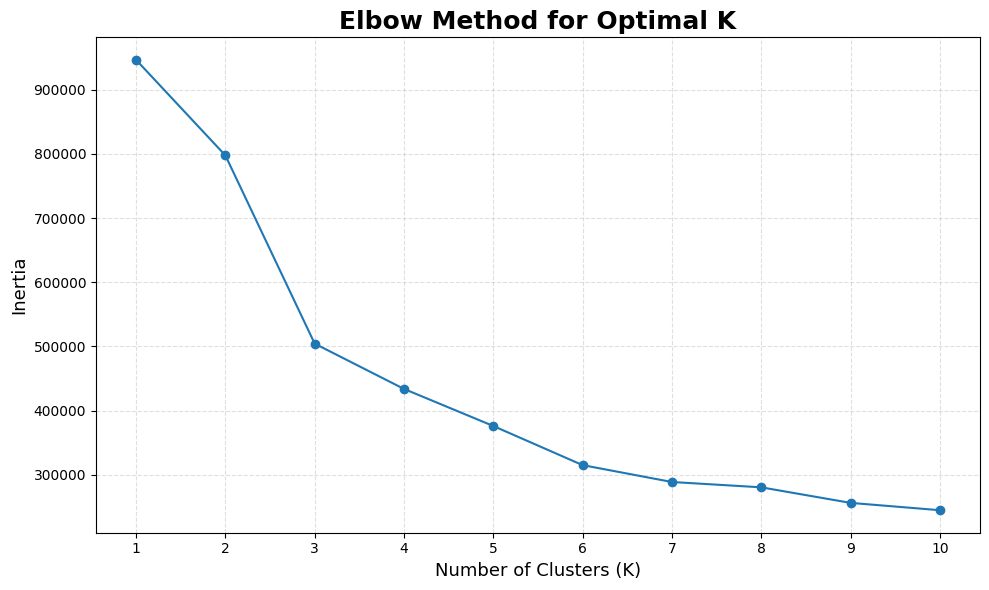

In [207]:
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.title(
    'Elbow Method for Optimal K',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Number of Clusters (K)',
    fontsize=13
)

plt.ylabel(
    'Inertia',
    fontsize=13
)

plt.xticks(k_values)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [208]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

In [209]:
kmeans.fit(scaled_data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [210]:
customer_features['cluster'] = (
    kmeans.labels_
)

In [211]:
customer_features['cluster'].value_counts()

cluster
2    66398
0    32304
1     6478
Name: count, dtype: int64

In [212]:
cluster_summary = (
    customer_features.groupby('cluster')[
        clustering_features
    ]
    .mean()
    .round(2)
)

cluster_summary

,total_orders,total_spend,avg_order_value,order_frequency,days_since_last_order,customer_cancel_rate,avg_delivery_delay,avg_rating,active_months
cluster,,,,,,,,,
0,2.30,766.18,335.02,0.01,117.08,5.69,5.71,3.13,2.11
1,1.19,43.73,21.84,0.00,141.17,91.60,7.84,0.07,1.15
2,1.01,354.34,350.78,0.00,167.79,0.07,5.55,2.02,1.00


##### Business Interpretation :
* 🔵 Cluster 0 — High-Value Loyal Customers
    * Characteristics
        * Highest total spend → 766
        * Higher order value → 335
        * Best activity duration
        * Low cancellation rate → 5.69%
        * Best ratings → 3.13
    * Meaning
        * These are: **Premium Loyal Customers**

* 🔴 Cluster 1 — Problematic / Churn-Risk Users
    * Characteristics
        * Extremely high cancellation rate → 91.6%
        * Worst ratings → 0.07
        * Highest delays → 7.84 mins
        * Lowest spend → 43
    * Meaning
        * These customers had: **Very Poor Experiences**

* 🟢 Cluster 2 — Casual / Inactive Users
    * Characteristics
        * Very few orders
        * Moderate spend
        * Long recency
        * Low activity
    * Meaning
        * These are: **Occasional Customers, but Not Unhappy**

### Cluster Visualization (PCA)

In [213]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

pca_components = pca.fit_transform(
    scaled_data
)

In [214]:
pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2']
)

pca_df['cluster'] = customer_features['cluster']

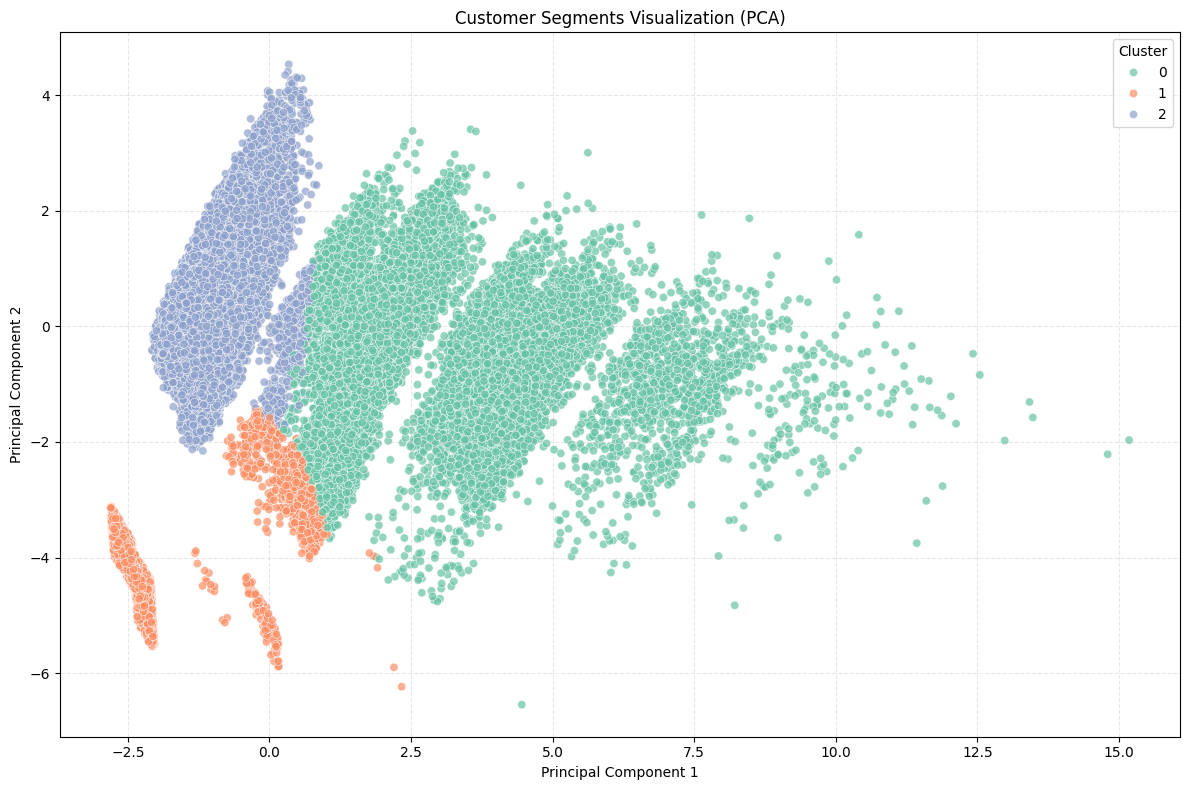

In [215]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    alpha=0.7
)

plt.title(
    'Customer Segments Visualization (PCA)'
)

plt.xlabel(
    'Principal Component 1'
)

plt.ylabel(
    'Principal Component 2'
)

plt.legend(
    title='Cluster'
)

plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [216]:
# Customers inactive for more than 90 days

inactive_customers = customer_features[
    customer_features['days_since_last_order'] > 90
]

# Count
inactive_count = inactive_customers.shape[0]

print(f"Customers inactive for more than 90 days: {inactive_count}")

Customers inactive for more than 90 days: 81050


In [217]:
inactive_percentage = (
    inactive_count / customer_features.shape[0]
) * 100

print(f"Percentage: {inactive_percentage:.2f}%")

Percentage: 77.06%


In [218]:
customer_features['is_churned'] = (
    customer_features['days_since_last_order'] > 90
).astype(int)

In [219]:
model_features = [
    
    'total_orders',
    'total_spend',
    'avg_order_value',
    'order_frequency',
    'customer_tenure_days',
    'customer_cancel_rate',
    'avg_delivery_delay',
    'avg_rating',
    'active_months',
    'favorite_restaurant_ratio',
    'avg_restaurant_prep_time_experienced'
]

In [220]:
X = customer_features[
    model_features
]

y = customer_features[
    'is_churned'
]

In [221]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.3,
    random_state=42,
    
    stratify=y
)

In [222]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    
    random_state=42,
    class_weight='balanced'
)

In [223]:
param_grid = {
    
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

In [224]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [225]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   3.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   3.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   3.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   3.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   3.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [226]:
grid_search.best_params_

{'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [227]:
grid_search.best_score_

np.float64(0.9325422260822572)

In [228]:
best_rf = grid_search.best_estimator_

In [229]:
y_pred = best_rf.predict(X_test)

In [230]:
from sklearn.metrics import (
    
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [231]:
y_train_pred = best_rf.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.9736


In [232]:
print(
    classification_report(
        y_train,
        y_train_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.97      0.94     16891
           1       0.99      0.97      0.98     56735

    accuracy                           0.97     73626
   macro avg       0.95      0.97      0.96     73626
weighted avg       0.97      0.97      0.97     73626



In [233]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8967


In [234]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.77      0.79      0.78      7239
           1       0.94      0.93      0.93     24315

    accuracy                           0.90     31554
   macro avg       0.85      0.86      0.86     31554
weighted avg       0.90      0.90      0.90     31554



In [235]:
feature_importance = pd.DataFrame({
    
    'Feature': model_features,
    
    'Importance': best_rf.feature_importances_
})

In [236]:
feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [237]:
top_feature = feature_importance.head(6)
top_feature

,Feature,Importance
4,customer_tenure_days,0.380466
6,avg_delivery_delay,0.166837
7,avg_rating,0.141206
8,active_months,0.074693
1,total_spend,0.072609
2,avg_order_value,0.064521


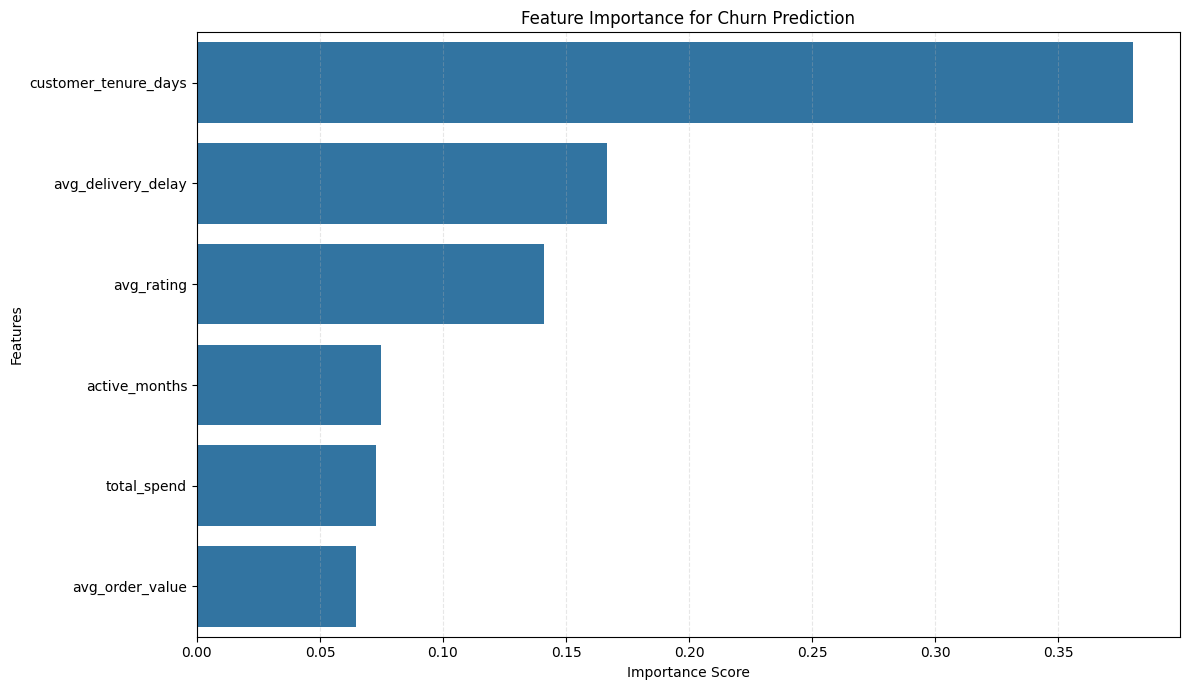

In [238]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_feature,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance for Churn Prediction'
)

plt.xlabel(
    'Importance Score'
)

plt.ylabel(
    'Features'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.show()

# Advanced Business Analytics Modules

## Revenue Driver Analysis

In [239]:
sales_features = [
    'order_frequency',
    'customer_tenure_days',
    'days_since_last_order',
    'customer_cancel_rate',
    'avg_delivery_delay',
    'avg_rating',
    'active_months',
    'favorite_restaurant_ratio',
    'avg_restaurant_prep_time_experienced'
]

In [240]:
target = 'total_spend'

In [241]:
X = customer_features[
    sales_features
]

y = customer_features[
    target
]

In [242]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.3,
    random_state=45
)

In [243]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(
    
    random_state=42
)

In [244]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

In [245]:
grid_search_reg = GridSearchCV(
    estimator=rf_regressor,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [246]:
grid_search_reg.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   2.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   3.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   3.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [247]:
grid_search_reg.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [248]:
grid_search_reg.best_score_

np.float64(0.7634571299661616)

In [249]:
best_rf_regressor = (
    grid_search_reg.best_estimator_
)

In [250]:
from sklearn.metrics import (
    
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [251]:
# Predictions on training data
y_train_pred = best_rf_regressor.predict(
    X_train
)

In [252]:
train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

print(f"Train MAE: {train_mae:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train R² Score: {train_r2:.4f}")

Train MAE: 98.96
Train RMSE: 133.21
Train R² Score: 0.7739


In [253]:
y_pred = best_rf_regressor.predict(
    X_test
)

In [254]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 101.79
RMSE: 137.41
R² Score: 0.7648


In [255]:
feature_importance = pd.DataFrame({

    'Feature': sales_features,

    'Importance': best_rf_regressor.feature_importances_
})

In [256]:
feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)
feature_importance

,Feature,Importance
0,order_frequency,0.329609
7,favorite_restaurant_ratio,0.298098
3,customer_cancel_rate,0.183420
6,active_months,0.125127
1,customer_tenure_days,0.045065
5,avg_rating,0.007549
2,days_since_last_order,0.006106
4,avg_delivery_delay,0.003287
8,avg_restaurant_prep_time_experienced,0.001740


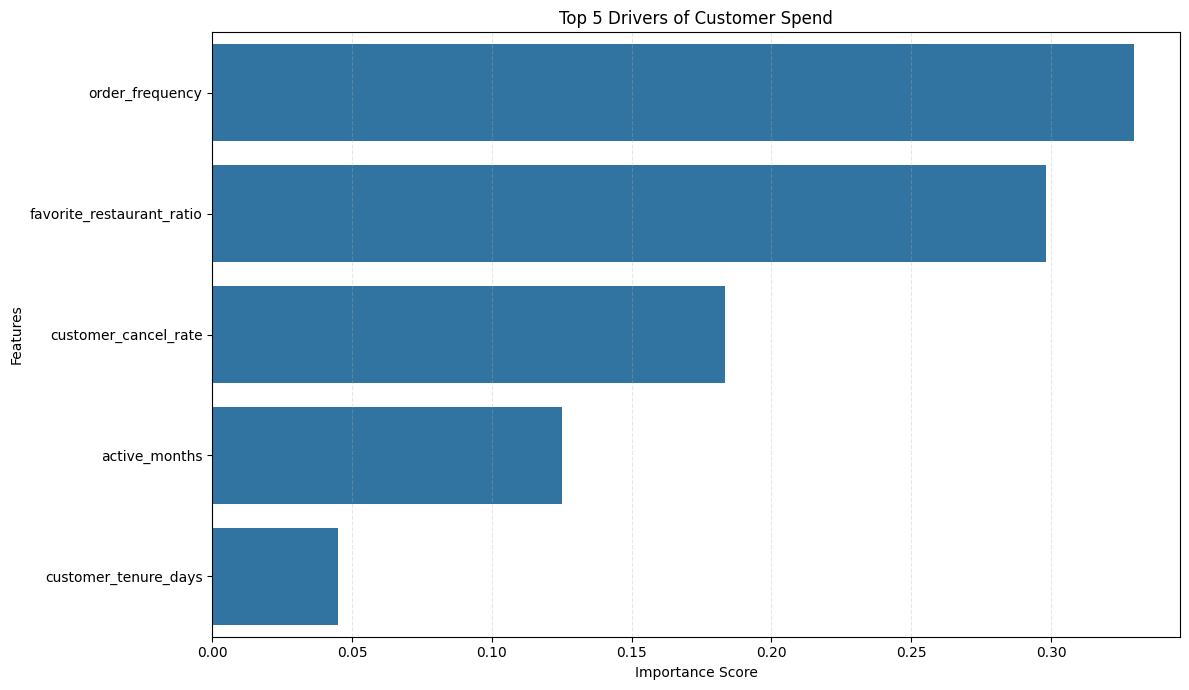

In [257]:
top_5 = feature_importance.head(5)

plt.figure(figsize=(12,7))

sns.barplot(
    data=top_5,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 5 Drivers of Customer Spend'
)

plt.xlabel(
    'Importance Score'
)

plt.ylabel(
    'Features'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.show()

## Revenue Growth Simulation

In [258]:
orders['crisis_flag'].value_counts()

crisis_flag
0    101415
1     47751
Name: count, dtype: int64

In [259]:
crisis_orders = orders[
    orders['crisis_flag'] == 1
]

In [260]:
crisis_start_date = '2025-05-15'

crisis_orders = orders[
    orders['order_timestamp'] >= crisis_start_date
].copy()

In [261]:
crisis_customer_features = (
    crisis_orders.groupby('customer_id')
    ['order_id']
    .count()
    .reset_index()
)

crisis_customer_features.columns = [
    'customer_id',
    'crisis_total_orders'
]

In [262]:
crisis_revenue = (
    crisis_orders.groupby('customer_id')
    ['total_amount']
    .sum()
    .reset_index()
)

crisis_revenue.columns = [
    'customer_id',
    'crisis_total_spend'
]

crisis_customer_features = crisis_customer_features.merge(
    crisis_revenue,
    on='customer_id',
    how='left'
)

In [263]:
crisis_orders['order_month'] = (
    crisis_orders['order_timestamp']
    .dt.to_period('M')
)

active_months = (
    crisis_orders.groupby('customer_id')
    ['order_month']
    .nunique()
    .reset_index()
)

active_months.columns = [
    'customer_id',
    'crisis_active_months'
]

crisis_customer_features = crisis_customer_features.merge(
    active_months,
    on='customer_id',
    how='left'
)

In [264]:
crisis_customer_features['crisis_orders_per_month'] = (
    crisis_customer_features['crisis_total_orders']
    /
    crisis_customer_features['crisis_active_months']
)

In [265]:
crisis_cancel_rate = (
    crisis_orders.groupby('customer_id')
    ['is_cancelled_flag']
    .mean()
    .reset_index()
)

crisis_cancel_rate.columns = [
    'customer_id',
    'crisis_cancel_rate'
]

crisis_cancel_rate['crisis_cancel_rate'] *= 100

crisis_customer_features = crisis_customer_features.merge(
    crisis_cancel_rate,
    on='customer_id',
    how='left'
)

In [266]:
customer_restaurant_orders = (
    crisis_orders.groupby(
        ['customer_id', 'restaurant_id']
    )['order_id']
    .count()
    .reset_index()
)

In [267]:
favorite_restaurant_orders = (
    customer_restaurant_orders.groupby('customer_id')
    ['order_id']
    .max()
    .reset_index()
)

favorite_restaurant_orders.columns = [
    'customer_id',
    'favorite_restaurant_orders'
]

In [268]:
crisis_customer_features = crisis_customer_features.merge(
    favorite_restaurant_orders,
    on='customer_id',
    how='left'
)

In [269]:
crisis_customer_features[
    'crisis_favorite_restaurant_ratio'
] = (
    crisis_customer_features['favorite_restaurant_orders']
    /
    crisis_customer_features['crisis_total_orders']
) * 100

In [270]:
crisis_ratings = ratings_orders[
    ratings_orders['order_timestamp'] >= crisis_start_date
]
crisis_avg_rating = (
    crisis_ratings.groupby('customer_id')
    ['rating']
    .mean()
    .reset_index()
)

crisis_avg_rating.columns = [
    'customer_id',
    'crisis_avg_rating'
]

In [271]:
crisis_customer_features = crisis_customer_features.merge(
    crisis_avg_rating,
    on='customer_id',
    how='left'
)

In [272]:
crisis_delivery = delivery_orders[
    delivery_orders['order_timestamp'] >= crisis_start_date
]
crisis_delay = (
    crisis_delivery.groupby('customer_id')
    ['delivery_delay']
    .mean()
    .reset_index()
)

crisis_delay.columns = [
    'customer_id',
    'crisis_avg_delivery_delay'
]

In [273]:
crisis_customer_features = crisis_customer_features.merge(
    crisis_delay,
    on='customer_id',
    how='left'
)

In [274]:
crisis_customer_features.head()

,customer_id,crisis_total_orders,crisis_total_spend,crisis_active_months,crisis_orders_per_month,crisis_cancel_rate,favorite_restaurant_orders,crisis_favorite_restaurant_ratio,crisis_avg_rating,crisis_avg_delivery_delay
0,CUST000009,2,652.69,2,1.0,0.0,1,50.0,NaN,16.5
1,CUST000010,1,245.72,1,1.0,0.0,1,100.0,4.1,4.0
2,CUST000014,1,207.05,1,1.0,0.0,1,100.0,3.0,-1.0
3,CUST000021,1,372.68,1,1.0,0.0,1,100.0,NaN,29.0
4,CUST000028,1,265.57,1,1.0,0.0,1,100.0,NaN,11.0


In [275]:
crisis_orders['order_month'] = (
    crisis_orders['order_timestamp']
    .dt.to_period('M')
)

monthly_crisis_revenue = (
    crisis_orders.groupby('order_month')
    ['total_amount']
    .sum()
    .reset_index()
)

monthly_crisis_revenue

,order_month,total_amount
0,2025-05,4092196.18
1,2025-06,2887866.91
2,2025-07,2724623.29
3,2025-08,2642856.29
4,2025-09,2684804.82


In [276]:
last_crisis_month = (
    monthly_crisis_revenue
    .sort_values('order_month')
    .iloc[-1]
)

baseline_revenue = (
    last_crisis_month['total_amount']
)

print(
    f"Baseline Revenue: ₹{baseline_revenue:,.2f}"
)

Baseline Revenue: ₹2,684,804.82


In [277]:
crisis_customer_features = crisis_customer_features.merge(
    customer_features[
        [
            'customer_id',
            'customer_tenure_days',
            'days_since_last_order',
            'avg_restaurant_prep_time_experienced'
        ]
    ],
    on='customer_id',
    how='left'
)

In [278]:
recovery_data = crisis_customer_features.copy()
recovery_data['order_frequency'] = recovery_data['crisis_orders_per_month']
recovery_data['customer_cancel_rate'] = recovery_data['crisis_cancel_rate']
recovery_data['avg_delivery_delay'] = recovery_data['crisis_avg_delivery_delay']
recovery_data['avg_rating'] = recovery_data['crisis_avg_rating']
recovery_data['active_months'] = recovery_data['crisis_active_months']
recovery_data['favorite_restaurant_ratio'] = (
    recovery_data['crisis_favorite_restaurant_ratio']
)

In [279]:
recovery_X = recovery_data[sales_features]

In [280]:
recovery_X_mod = recovery_X.copy()
recovery_X_mod['order_frequency'] *= 1.20 # +20%
recovery_X_mod['favorite_restaurant_ratio'] *= 1.10 # +10%
recovery_X_mod['customer_cancel_rate'] *= 0.70 # -30%
recovery_X_mod['active_months'] *= 1.20 # +20

In [281]:
baseline_predicted_revenue = (
    best_rf_regressor.predict(recovery_X)
)

baseline_revenue = baseline_predicted_revenue.sum()

print(f"Baseline Revenue: ₹{baseline_revenue:,.2f}")

Baseline Revenue: ₹31,151,014.02


In [282]:
# Predict recovered revenue
projected_revenue = best_rf_regressor.predict(
    recovery_X_mod
)

projected_revenue_total = projected_revenue.sum()

print(f"Projected Revenue: ₹{projected_revenue_total:,.2f}")

Projected Revenue: ₹32,135,903.20


In [283]:
growth_pct = (
    (projected_revenue - baseline_predicted_revenue)
    / baseline_predicted_revenue
) * 100

In [284]:
actual_crisis_revenue = 2684804.82

recovered_revenue = (
    actual_crisis_revenue
    * (1 + growth_pct/100)
)

incremental_revenue = (
    recovered_revenue
    - actual_crisis_revenue
)

In [285]:
# Last crisis month revenue
last_crisis_month = (
    monthly_crisis_revenue
    .sort_values('order_month')
    .iloc[-1]
)

actual_crisis_revenue = last_crisis_month['total_amount']


# Revenue growth from simulation
growth_pct = (
    (projected_revenue_total - baseline_revenue) # type: ignore
    / baseline_revenue
) * 100

# Projected recovery revenue
recovered_revenue = (
    actual_crisis_revenue
    * (1 + growth_pct/100)
)

incremental_revenue = (
    recovered_revenue
    - actual_crisis_revenue
)

print(f"Last Crisis Month: {last_crisis_month['order_month']}")
print(f"Current Crisis Revenue: ₹{actual_crisis_revenue:,.2f}")
print(f"Revenue Growth: {growth_pct:.2f}%")
print(f"Projected Revenue: ₹{recovered_revenue:,.2f}")
print(f"Incremental Revenue Gain: ₹{incremental_revenue:,.2f}")

Last Crisis Month: 2025-09
Current Crisis Revenue: ₹2,684,804.82
Revenue Growth: 3.16%
Projected Revenue: ₹2,769,689.22
Incremental Revenue Gain: ₹84,884.40


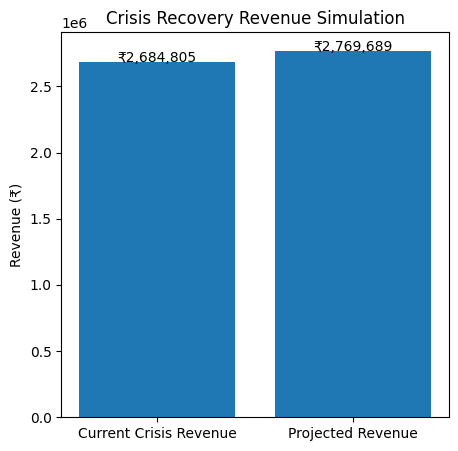

In [286]:
import matplotlib.pyplot as plt

current_revenue = actual_crisis_revenue
projected_revenue = recovered_revenue

plt.figure(figsize=(5,5))

plt.bar(
    ['Current Crisis Revenue', 'Projected Revenue'],
    [current_revenue, projected_revenue]
)

plt.title('Crisis Recovery Revenue Simulation')
plt.ylabel('Revenue (₹)')

for i, v in enumerate([current_revenue, projected_revenue]):
    plt.text(i, v, f'₹{v:,.0f}', ha='center')

plt.show()

In [287]:
print(f"Current Revenue      : ₹{current_revenue:,.2f}")
print(f"Projected Revenue    : ₹{projected_revenue:,.2f}")
print(f"Incremental Gain     : ₹{incremental_revenue:,.2f}")
print(f"Revenue Growth       : {growth_pct:.2f}%")

Current Revenue      : ₹2,684,804.82
Projected Revenue    : ₹2,769,689.22
Incremental Gain     : ₹84,884.40
Revenue Growth       : 3.16%


## Top Restaurant Intelligence

In [288]:
restaurant_performance = (
    orders.groupby('restaurant_id')
    .agg(
        total_orders=('order_id', 'count'),
        total_revenue=('total_amount', 'sum'),
        avg_order_value=('total_amount', 'mean')
    )
    .reset_index()
)

restaurant_performance = restaurant_performance.merge(
    restaurants,
    on='restaurant_id',
    how='left'
)

restaurant_performance.head()

,restaurant_id,total_orders,total_revenue,avg_order_value,restaurant_name,city,cuisine_type,partner_type,avg_prep_time_min,is_active,midpoint_prep_time_min
0,REST00001,6,2313.23,385.538333,Madras House Central,Delhi,Pizza,Restaurant,16-25,Y,20.5
1,REST00002,11,3269.26,297.205455,Namma Kitchen Clouds,Ahmedabad,Chinese,Restaurant,>40,N,NaN
2,REST00003,8,2106.09,263.261250,Taste of Wraps Nest,Mumbai,Healthy,Restaurant,16-25,Y,20.5
3,REST00004,7,1693.33,241.904286,Grand Thali Delight,Hyderabad,South Indian,Cloud Kitchen,16-25,Y,20.5
4,REST00005,14,5328.94,380.638571,Taste of Curry Zone,Bengaluru,Fast Food,Restaurant,16-25,Y,20.5


In [289]:
restaurant_ratings = (
    ratings_orders.groupby('restaurant_id')
    ['rating']
    .mean()
    .reset_index()
)

restaurant_ratings.columns = [
    'restaurant_id',
    'avg_customer_rating'
]

restaurant_performance = restaurant_performance.merge(
    restaurant_ratings,
    on='restaurant_id',
    how='left'
)

In [290]:
top_revenue_restaurants = (
    restaurant_performance
    .sort_values('total_revenue', ascending=False)
    .head(10)
)

top_revenue_restaurants[
    ['restaurant_name','city','total_revenue']
]

,restaurant_name,city,total_revenue
16766,Hot & Crispy Pizza Bhojanalay,Kolkata,8318.71
13399,Punjabi Darshini Palace,Ahmedabad,7184.13
17729,Hot & Crispy Paratha Zone,Kolkata,6831.62
16515,Thindi Mane Grill Palace,Kolkata,6689.00
11683,Punjabi Wraps Bhojanalay,Kolkata,6529.90
3370,Fresh Thali Adda,Mumbai,6354.94
19280,Thindi Mane House Hub,Bengaluru,6346.58
18502,Punjabi Curry Delight,Bengaluru,6288.66
15699,Spicy Delights Bhojanalay,Kolkata,6279.69
12658,Namma Darshini Stop,Bengaluru,6244.89


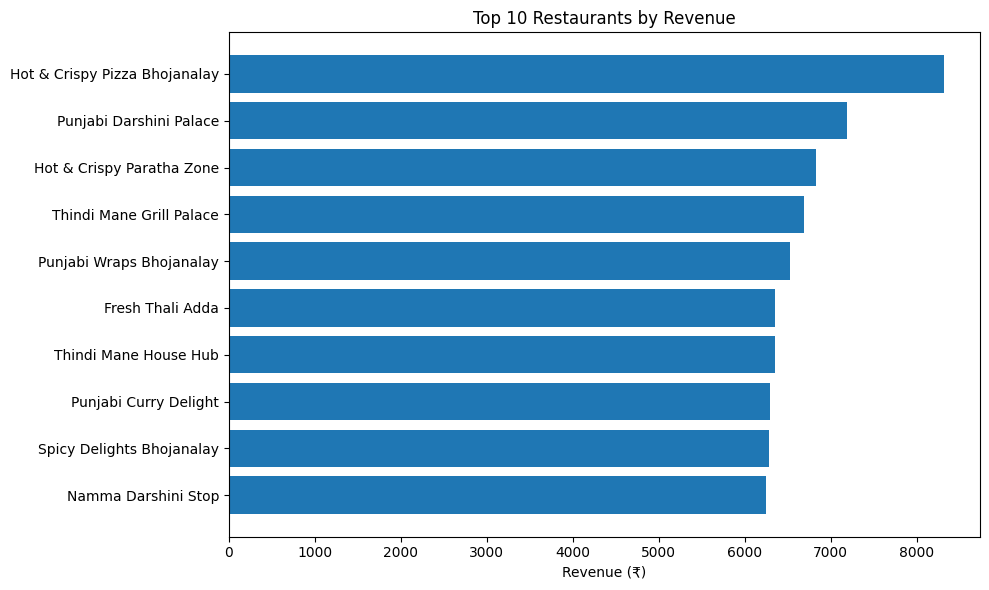

In [291]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top10 = top_revenue_restaurants.sort_values(
    'total_revenue'
)

plt.barh(
    top10['restaurant_name'],
    top10['total_revenue']
)

plt.title('Top 10 Restaurants by Revenue')
plt.xlabel('Revenue (₹)')
plt.tight_layout()
plt.show()

In [292]:
top_orders_restaurants = (
    restaurant_performance
    .sort_values('total_orders', ascending=False)
    .head(10)
)

top_orders_restaurants[
    ['restaurant_name','city','total_orders']
]

,restaurant_name,city,total_orders
16766,Hot & Crispy Pizza Bhojanalay,Kolkata,23
16515,Thindi Mane Grill Palace,Kolkata,23
19280,Thindi Mane House Hub,Bengaluru,21
13199,Kolkata House Zone,Mumbai,21
11683,Punjabi Wraps Bhojanalay,Kolkata,21
3370,Fresh Thali Adda,Mumbai,21
13399,Punjabi Darshini Palace,Ahmedabad,20
12658,Namma Darshini Stop,Bengaluru,19
12323,Hot & Crispy Express Darbar,Kolkata,19
11749,Sri Mess Zone,Pune,18


In [293]:
top_rated_restaurants = (
    restaurant_performance[
        restaurant_performance['total_orders'] >= 15
    ]
    .sort_values(
        'avg_customer_rating',
        ascending=False
    )
    .head(10)
)

top_rated_restaurants[
    ['restaurant_name',
     'city',
     'avg_customer_rating']
]

,restaurant_name,city,avg_customer_rating
13860,Thindi Mane Pizza Corner,Hyderabad,4.850000
18799,Delhi Sweets Nest,Kolkata,4.814286
19907,Sri Curry Central,Bengaluru,4.766667
2220,Tandoori Cafe Delight,Chennai,4.700000
12323,Hot & Crispy Express Darbar,Kolkata,4.655556
1547,Urban Express Palace,Bengaluru,4.650000
9048,Sri Wraps Clouds,Delhi,4.650000
6246,Spicy Delights Clouds,Ahmedabad,4.640000
16996,Annapurna Express Stop,Delhi,4.633333
18502,Punjabi Curry Delight,Bengaluru,4.616667


In [294]:
city_top_restaurants = (
    restaurant_performance
    .sort_values(
        ['city','total_revenue'],
        ascending=[True,False]
    )
    .groupby('city')
    .head(5)
)

city_top_restaurants[
    ['city',
     'restaurant_name',
     'total_revenue',
     'total_orders']
]

,city,restaurant_name,total_revenue,total_orders
13399,Ahmedabad,Punjabi Darshini Palace,7184.13,20
7308,Ahmedabad,Bombay Kitchen Heaven,6108.60,16
5734,Ahmedabad,Kolkata Mess Darbar,6010.49,14
1438,Ahmedabad,Royal Paratha Corner,5915.69,13
8174,Ahmedabad,Namma Darshini Clouds,5867.67,14
19280,Bengaluru,Thindi Mane House Hub,6346.58,21
18502,Bengaluru,Punjabi Curry Delight,6288.66,17
12658,Bengaluru,Namma Darshini Stop,6244.89,19
10186,Bengaluru,Grand Express Bhojanalay,6176.52,17
3132,Bengaluru,Urban Thali Heaven,5943.43,15


In [295]:
revenue_restaurants = (
    restaurant_performance
    .sort_values('total_revenue', ascending=False)
)

In [296]:
revenue_restaurants['total_revenue'].describe()

count    19983.000000
mean      2430.121381
std        976.635520
min          0.000000
25%       1734.290000
50%       2349.740000
75%       3061.095000
max       8318.710000
Name: total_revenue, dtype: float64

In [297]:
import numpy as np

restaurant_performance['performance_tier'] = np.select(
    [
        revenue_restaurants['total_revenue'] > 5000,
        revenue_restaurants['total_revenue'] > 2500,
        revenue_restaurants['total_revenue'] > 1500
    ],
    [
        'Elite',
        'High',
        'Medium'
    ],
    default='Low'
)

In [298]:
restaurant_performance[
    'performance_tier'
].value_counts()

performance_tier
High      8579
Medium    7802
Low       3395
Elite      207
Name: count, dtype: int64

In [299]:
tier_summary = (
    restaurant_performance.groupby('performance_tier')
    .agg(
        restaurants=('restaurant_id', 'count'),
        total_revenue=('total_revenue', 'sum'),
        total_orders=('total_orders', 'sum'),
        avg_rating=('avg_customer_rating', 'mean')
    )
)

tier_summary['revenue_share_pct'] = (
    tier_summary['total_revenue']
    / tier_summary['total_revenue'].sum()
    * 100
).round(2)

tier_summary

,restaurants,total_revenue,total_orders,avg_rating,revenue_share_pct
performance_tier,,,,,
Elite,207,523032.81,1588,3.992200,1.08
High,8579,20817414.31,63915,4.060783,42.87
Low,3395,8259449.33,25300,4.052285,17.01
Medium,7802,18961219.11,58363,4.045657,39.05


In [300]:
attention_restaurants = (
    restaurant_performance[
        (restaurant_performance['avg_customer_rating'] < 3.5)
        &
        (restaurant_performance['total_orders'] > 15)
    ]
)

attention_restaurants[
    ['restaurant_name',
     'city',
     'avg_customer_rating',
     'total_orders']
]

,restaurant_name,city,avg_customer_rating,total_orders
1575,Madras Thali Stop,Kolkata,3.485714,16
3771,Kolkata Biryani Hub,Hyderabad,3.350000,16
7205,Fresh Biryani Cafe,Hyderabad,3.350000,17
11205,Urban Curry Stop,Chennai,3.430000,16


## Delivery Partner Segmentation

In [301]:
partner_performance = (
    delivery_orders.groupby('delivery_partner_id')
    .agg(
        total_deliveries=('order_id', 'count'),
        avg_delivery_delay=('delivery_delay', 'mean'),
        sla_breach_rate=('sla_breach', 'mean')
    )
    .reset_index()
)

partner_performance.head()

,delivery_partner_id,total_deliveries,avg_delivery_delay,sla_breach_rate
0,DP00001,13,8.076923,0.615385
1,DP00002,8,-0.750000,0.625000
2,DP00003,9,3.111111,0.444444
3,DP00004,10,6.400000,0.600000
4,DP00005,12,3.166667,0.583333


In [302]:
partner_performance = partner_performance.merge(
    del_partner[
        ['delivery_partner_id', 'avg_rating']
    ],
    on='delivery_partner_id',
    how='left'
)

In [303]:
partner_performance[['delivery_partner_id', 'avg_rating']].head()

,delivery_partner_id,avg_rating
0,DP00001,3.96
1,DP00002,4.22
2,DP00003,4.45
3,DP00004,3.93
4,DP00005,4.42


In [304]:
partner_ontime = (
    delivery_orders.assign(
        on_time=delivery_orders['delivery_delay'] <= 0
    )
    .groupby('delivery_partner_id')['on_time']
    .mean()
    .reset_index()
)

partner_ontime.rename(
    columns={'on_time': 'on_time_pct'},
    inplace=True
)

partner_ontime['on_time_pct'] *= 100

partner_ontime.head()

,delivery_partner_id,on_time_pct
0,DP00001,38.461538
1,DP00002,37.500000
2,DP00003,55.555556
3,DP00004,40.000000
4,DP00005,41.666667


In [305]:
partner_performance = partner_performance.merge(
    partner_ontime,
    on='delivery_partner_id',
    how='left'
)

In [306]:
partner_performance['on_time_pct'].describe()

count    15000.000000
mean        36.356096
std         16.773220
min          0.000000
25%         25.000000
50%         36.363636
75%         46.666667
max        100.000000
Name: on_time_pct, dtype: float64

In [307]:
# Segment Delivery Partners

partner_performance['partner_segment'] = np.select(
    [
        (partner_performance['on_time_pct'] >= 95) &
        (partner_performance['avg_rating'] >= 4.5),

        (partner_performance['on_time_pct'] >= 90) &
        (partner_performance['avg_rating'] >= 4.0),

        (partner_performance['on_time_pct'] >= 80)
    ],
    [
        'Star',
        'Reliable',
        'Average'
    ],
    default='Needs Improvement'
)

In [308]:
partner_summary = (
    partner_performance.groupby('partner_segment')
    .agg(
        partners=('delivery_partner_id', 'count'),
        deliveries=('total_deliveries', 'sum'),
        avg_delay=('avg_delivery_delay', 'mean'),
        avg_rating=('avg_rating', 'mean'),
        avg_on_time_pct=('on_time_pct', 'mean')
    )
    .round(2)
)

partner_summary

,partners,deliveries,avg_delay,avg_rating,avg_on_time_pct
partner_segment,,,,,
Average,133,823,-2.98,4.18,83.23
Needs Improvement,14838,142589,5.73,4.20,35.81
Reliable,23,94,-4.92,4.23,99.17
Star,6,25,-6.27,4.74,100.00


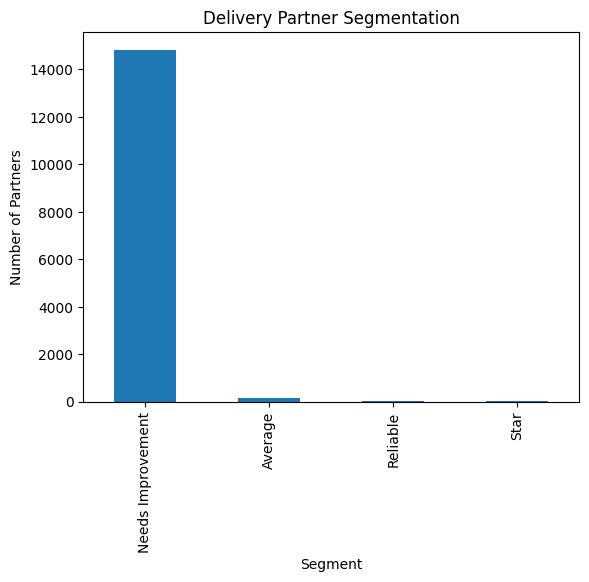

In [309]:
import matplotlib.pyplot as plt

partner_performance['partner_segment'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Delivery Partner Segmentation')
plt.xlabel('Segment')
plt.ylabel('Number of Partners')
plt.show()

In [310]:
top_partners = (
    partner_performance
    .sort_values(
        ['on_time_pct', 'avg_rating'],
        ascending=False
    )
    .head(20)
)

top_partners[
    [
        'delivery_partner_id',
        'total_deliveries',
        'avg_rating',
        'on_time_pct',
        'avg_delivery_delay'
    ]
]

,delivery_partner_id,total_deliveries,avg_rating,on_time_pct,avg_delivery_delay
11988,DP11989,6,4.98,100.0,-5.500000
7938,DP07939,4,4.79,100.0,-3.250000
14839,DP14840,4,4.76,100.0,-8.250000
10603,DP10604,3,4.71,100.0,-5.333333
7903,DP07904,3,4.68,100.0,-7.666667
8391,DP08392,5,4.50,100.0,-7.600000
14323,DP14324,2,4.46,100.0,-6.000000
1699,DP01700,5,4.45,100.0,-2.800000
7607,DP07608,3,4.44,100.0,-8.000000
166,DP00167,4,4.42,100.0,-8.000000


In [311]:
# Bonus Candidates
bonus_candidates = (
    partner_performance[
        (partner_performance['on_time_pct'] >= 95)
        &
        (partner_performance['avg_rating'] >= 4.5)
    ]
    .sort_values(
        ['on_time_pct', 'avg_rating'],
        ascending=False
    )
)

bonus_candidates.head(20)

,delivery_partner_id,total_deliveries,avg_delivery_delay,sla_breach_rate,avg_rating,on_time_pct,partner_segment
11988,DP11989,6,-5.500000,0.0,4.98,100.0,Star
7938,DP07939,4,-3.250000,0.0,4.79,100.0,Star
14839,DP14840,4,-8.250000,0.0,4.76,100.0,Star
10603,DP10604,3,-5.333333,0.0,4.71,100.0,Star
7903,DP07904,3,-7.666667,0.0,4.68,100.0,Star
8391,DP08392,5,-7.600000,0.0,4.50,100.0,Star


In [312]:
poor_partners = (
    partner_performance[
        (partner_performance['on_time_pct'] < 80)
    ]
    .sort_values('on_time_pct')
)

poor_partners.head(20)

,delivery_partner_id,total_deliveries,avg_delivery_delay,sla_breach_rate,avg_rating,on_time_pct,partner_segment
12128,DP12129,5,19.400000,1.0,4.40,0.0,Needs Improvement
5419,DP05420,5,9.800000,1.0,4.44,0.0,Needs Improvement
9257,DP09258,6,9.666667,1.0,4.06,0.0,Needs Improvement
7541,DP07542,4,8.250000,1.0,4.42,0.0,Needs Improvement
11627,DP11628,9,10.666667,1.0,4.13,0.0,Needs Improvement
13991,DP13992,6,14.000000,1.0,4.23,0.0,Needs Improvement
11053,DP11054,6,19.333333,1.0,4.94,0.0,Needs Improvement
3896,DP03897,8,10.250000,1.0,4.26,0.0,Needs Improvement
12543,DP12544,5,12.800000,1.0,4.21,0.0,Needs Improvement
9687,DP09688,6,6.833333,1.0,4.06,0.0,Needs Improvement


In [313]:
partner_performance = partner_performance.merge(
    del_partner[
        [
            'delivery_partner_id',
            'vehicle_type'
        ]
    ],
    on='delivery_partner_id',
    how='left'
)

In [314]:
vehicle_analysis = (
    partner_performance.groupby('vehicle_type')
    .agg(
        partners=('delivery_partner_id', 'count'),
        avg_delay=('avg_delivery_delay', 'mean'),
        avg_on_time=('on_time_pct', 'mean')
    )
    .round(2)
)

vehicle_analysis

,partners,avg_delay,avg_on_time
vehicle_type,,,
Bike,5941,5.66,36.45
Car,792,5.30,37.90
Cycle,2256,5.66,36.19
Scooter,6011,5.64,36.12


In [315]:
# Partner Segmentation by City
partner_performance = partner_performance.merge(
    del_partner[
        ['delivery_partner_id', 'city']
    ],
    on='delivery_partner_id',
    how='left'
)

In [316]:
city_partner_segments = (
    partner_performance
    .groupby(['city', 'partner_segment'])
    .size()
    .unstack(fill_value=0)
)

city_partner_segments

partner_segment,Average,Needs Improvement,Reliable,Star
city,,,,
Ahmedabad,9,1200,3,0
Bengaluru,38,3733,2,2
Chennai,9,1548,2,0
Delhi,21,2182,3,1
Hyderabad,8,1432,4,1
Kolkata,16,1362,4,0
Mumbai,23,2199,4,1
Pune,9,1182,1,1


In [317]:
city_partner_pct = (
    city_partner_segments.div(
        city_partner_segments.sum(axis=1),
        axis=0
    ) * 100
).round(2)

city_partner_pct

partner_segment,Average,Needs Improvement,Reliable,Star
city,,,,
Ahmedabad,0.74,99.01,0.25,0.00
Bengaluru,1.01,98.89,0.05,0.05
Chennai,0.58,99.29,0.13,0.00
Delhi,0.95,98.87,0.14,0.05
Hyderabad,0.55,99.10,0.28,0.07
Kolkata,1.16,98.55,0.29,0.00
Mumbai,1.03,98.74,0.18,0.04
Pune,0.75,99.08,0.08,0.08


In [318]:
city_performance = (
    partner_performance.groupby('city')
    .agg(
        partners=('delivery_partner_id', 'count'),
        avg_rating=('avg_rating', 'mean'),
        avg_delay=('avg_delivery_delay', 'mean'),
        avg_on_time_pct=('on_time_pct', 'mean')
    )
    .round(2)
    .sort_values('avg_on_time_pct', ascending=False)
)

city_performance

,partners,avg_rating,avg_delay,avg_on_time_pct
city,,,,
Mumbai,2227,4.19,5.65,36.91
Kolkata,1382,4.20,5.54,36.65
Pune,1193,4.19,5.62,36.60
Bengaluru,3775,4.20,5.65,36.46
Ahmedabad,1212,4.20,5.62,36.10
Delhi,2207,4.20,5.60,36.09
Chennai,1559,4.21,5.58,35.94
Hyderabad,1445,4.20,5.77,35.82
